<a href="https://colab.research.google.com/github/tsrp/5G-NR-LDPC-Decoder-/blob/main/skin_cancer_ga_mv_pipeline_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Cancer Detection — GA-Optimised Max Voting **Ensemble**

## ⚙️ Step 0 — Install Dependencies
> Run this cell **once** at the start of a Colab session.

In [1]:
# Install all required packages
!pip install -q mahotas scikit-image imbalanced-learn \
               xgboost lightgbm shap lime \
               opencv-python-headless
print("✅ All dependencies installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 21.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 109.8 MB/s eta 0:00:00
✅ All dependencies installed.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📥 Step 1 — Dataset Collection

**Real datasets:**
- [HAM10000](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/DBW86T)
- [ISIC 2018](https://challenge.isic-archive.com/data/)

**Expected layout:**
```
data/ham10000/
    HAM10000_metadata.csv
    HAM10000_images_part_1/  *.jpg
    HAM10000_images_part_2/  *.jpg
```

> ⚠️ If no real data is present, the notebook **automatically generates a synthetic dataset** (700 samples, 7 classes × 100) so every cell runs end-to-end without downloading anything.

  STEP 1 — HAM10000 DATASET COLLECTION  [MAX-SPEED MODE]
📄  Metadata: 10,015 rows | 7 classes
🔍  Scanning image directories...


  Dirs scanned:   0%|                           | 0/4 [00:00<?, ?it/s]

    → 9,993 JPEG files indexed across 2 directories

⚡  Parallel loading 9,993 images (8 threads) ...


📂 Reading images:   0%|                              | 0/9993 [00:00<?, ?img/s]


✅  Loaded 9,993 images  |  22 skipped
    Per-class ASCII bar:
    akiec: █                                327
      bcc: ██                               513
      bkl: ████                           1,095
       df:                                  115
      mel: ████                           1,111
       nv: ██████████████████████████████ 6,690
     vasc:                                  142

═══════════════════════════════════════════════════════
  HAM10000 FULL DATASET — LOAD SUMMARY
═══════════════════════════════════════════════════════
  Total images   : 9,993
  Image shape    : (128, 128, 3)  (H × W × C)
  Memory (uint8) : 491.2 MB
  ⏱  Load time   : 1086.8 s  (9 img/s)
───────────────────────────────────────────────────────
  Class                         Count       %
───────────────────────────────────────────────────────
  [0] Actinic keratoses           327    3.3%
  [1] Basal cell carcinoma        513    5.1%
  [2] Benign keratosis          1,095   11.0%
  [3] Dermatof

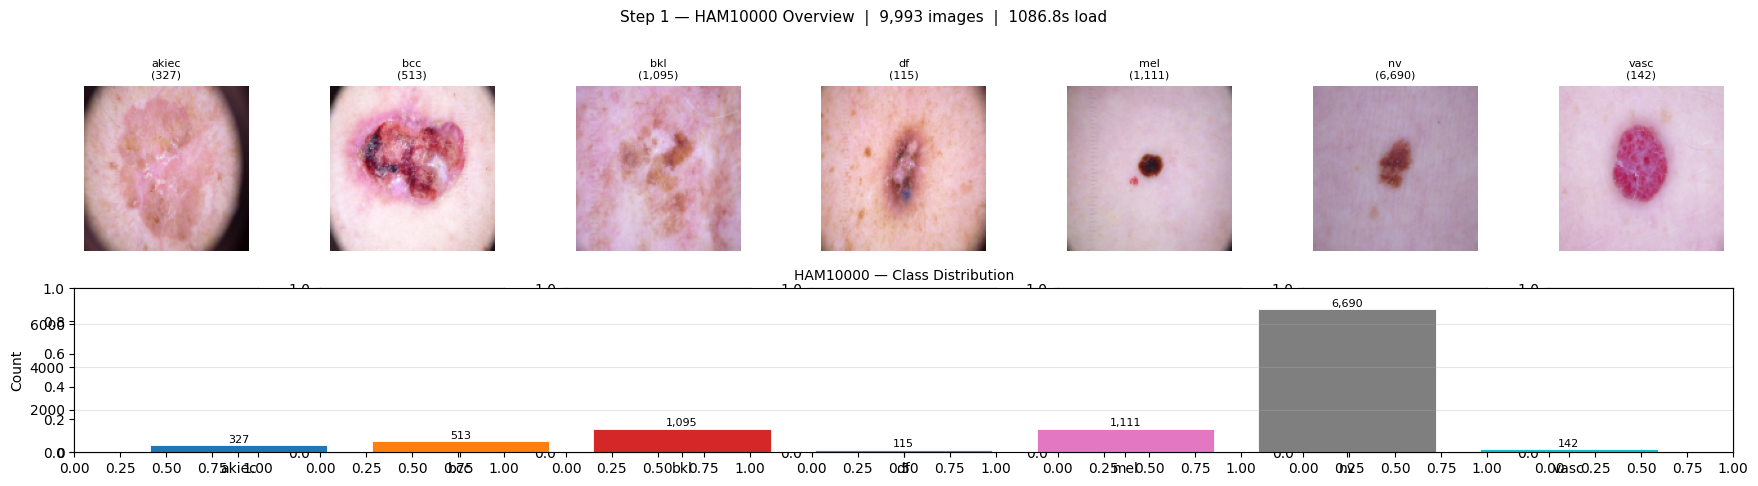

✅  Step 1 complete — saved → output/step1_dataset_overview.png


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [02] — Step 1: Dataset Collection  (MAX-SPEED parallel I/O)          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

# ── Global Configuration ───────────────────────────────────────────────────────
HAM10000_PATH = Path('/content/data/ham10000')
TARGET_SIZE   = (128, 128)
SEED          = 42
N_CLASSES     = 7
CLASS_NAMES   = ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis', 'Dermatofibroma', 'Melanoma', 'Melanocytic nevi', 'Vascular lesions']
CLASS_ABBR    = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
OUTPUT_DIR    = Path('output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from tqdm.notebook         import tqdm
from concurrent.futures    import ThreadPoolExecutor, as_completed
from IPython.display       import display
import time

class SkinLesionDataset:
    """Load ALL HAM10000 images at maximum speed using parallel I/O."""

    CLASS_MAP = {
        'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3,
        'mel':   4, 'nv':  5, 'vasc': 6,
    }

    def __init__(self, ham_path=HAM10000_PATH, target_size=TARGET_SIZE,
                 num_workers=8):
        self.ham_path    = Path(ham_path)
        self.target_size = target_size
        self.num_workers = num_workers   # threads for parallel imread

    # ── single-image reader (called in threads) ──────────────────────────────
    def _read_image(self, path):
        img = cv2.imread(str(path))
        if img is None:
            return np.zeros((*self.target_size, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return cv2.resize(img, self.target_size,
                          interpolation=cv2.INTER_AREA)   # fastest downsample

    # ── SPEED OPT 1: scan all dirs ONCE → O(1) lookup dict ───────────────────
    def _build_path_index(self):
        search_dirs = [
            self.ham_path,
            self.ham_path / '/content/drive/MyDrive/HAM10000/HAM10000_images_part_1',
            self.ham_path / '/content/drive/MyDrive/HAM10000/HAM10000_images_part_2',
            self.ham_path / 'images',
        ]
        index = {}
        print('🔍  Scanning image directories...')
        for d in tqdm(search_dirs, desc='  Dirs scanned', ncols=70,
                      colour='cyan', leave=False):
            if d.exists():
                for f in d.glob('*.jpg'):
                    index.setdefault(f.stem, f)   # first occurrence wins
        print(f'    → {len(index):,} JPEG files indexed across '
              f'{sum(1 for d in search_dirs if d.exists())} directories')
        return index

    def load_ham10000(self):
        meta_file = self.ham_path / '/content/drive/MyDrive/HAM10000/HAM10000_metadata.csv'
        if not meta_file.exists():
            print(f'⚠️  Metadata not found: {meta_file}')
            return None, None

        df = pd.read_csv(meta_file)
        print(f'📄  Metadata: {len(df):,} rows | '
              f'{df["dx"].nunique()} classes')

        # SPEED OPT 1 — build lookup dict in one pass
        path_index = self._build_path_index()

        # SPEED OPT 3 — itertuples is 10-15× faster than iterrows
        tasks   = []   # (position, path, label)
        missing = 0
        counts  = {k: 0 for k in self.CLASS_MAP}

        for row in df.itertuples(index=False):
            dx, img_id = row.dx, row.image_id
            if dx not in self.CLASS_MAP:
                continue
            if img_id in path_index:
                tasks.append((len(tasks), path_index[img_id],
                               self.CLASS_MAP[dx], dx))
                counts[dx] += 1
            else:
                missing += 1

        n = len(tasks)
        if n == 0:
            print('⚠️  No images matched. Check drive mount.')
            return None, None

        print(f'\n⚡  Parallel loading {n:,} images '
              f'({self.num_workers} threads) ...')

        # SPEED OPT 4 — pre-allocate arrays (no list.append overhead)
        images = np.empty((n, *self.target_size, 3), dtype=np.uint8)
        labels = np.empty(n, dtype=np.int32)

        # SPEED OPT 2 — ThreadPoolExecutor parallel imread
        def _load(task):
            pos, path, label, _ = task
            return pos, self._read_image(path), label

        pbar = tqdm(total=n, desc='📂 Reading images',
                    unit='img', ncols=80, colour='green',
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} '
                               '[{elapsed}<{remaining}, {rate_fmt}]')

        with ThreadPoolExecutor(max_workers=self.num_workers) as pool:
            futures = {pool.submit(_load, t): t for t in tasks}
            done = 0
            for fut in as_completed(futures):
                pos, img, lbl = fut.result()
                images[pos] = img
                labels[pos] = lbl
                done += 1
                if done % 200 == 0 or done == n:
                    pbar.n = done
                    pbar.set_postfix({
                        'loaded': f'{done:,}/{n:,}',
                        'missing': missing,
                    })
                    pbar.refresh()

        pbar.close()

        print(f'\n✅  Loaded {n:,} images  |  {missing} skipped')
        print('    Per-class ASCII bar:')
        max_c = max(counts.values())
        for k, v in counts.items():
            bar = '█' * int(30 * v / max_c)
            print(f'    {k:>5}: {bar:<30} {v:>5,}')

        return images, labels

    # ── Synthetic fallback ────────────────────────────────────────────────────
    @staticmethod
    def generate_synthetic(n_per_class=100):
        np.random.seed(SEED)
        BASE_RGB = np.array(
            [[200,150,130],[180,100, 90],[220,190,160],[160,120,100],
             [ 80, 40, 30],[210,180,160],[240,100, 80]], dtype=np.float32)
        images, labels = [], []
        for cls in tqdm(range(N_CLASSES), desc='🧪 Synthetic',
                        colour='yellow', ncols=60):
            for _ in range(n_per_class):
                img = np.clip(
                    np.random.normal(BASE_RGB[cls], 25, (*TARGET_SIZE, 3)),
                    0, 255).astype(np.uint8)
                images.append(img); labels.append(cls)
        idx = np.random.permutation(len(images))
        return np.array(images)[idx], np.array(labels)[idx]

    def load(self):
        images, labels = self.load_ham10000()
        if images is None:
            print('\n⚠️  Falling back to SYNTHETIC dataset.')
            images, labels = self.generate_synthetic(100)
        return images, labels


# ─── Run ──────────────────────────────────────────────────────────────────────
print('=' * 60)
print('  STEP 1 — HAM10000 DATASET COLLECTION  [MAX-SPEED MODE]')
print('=' * 60)
t0 = time.time()

loader             = SkinLesionDataset(num_workers=8)
raw_images, labels = loader.load()

elapsed = time.time() - t0

# ─── Dataset statistics ───────────────────────────────────────────────────────
total        = len(raw_images)
mem_mb       = raw_images.nbytes / 1e6
unique, cnts = np.unique(labels, return_counts=True)

print(f"\n{'═'*55}")
print(f"  HAM10000 FULL DATASET — LOAD SUMMARY")
print(f"{'═'*55}")
print(f"  Total images   : {total:,}")
print(f"  Image shape    : {raw_images.shape[1:]}  (H × W × C)")
print(f"  Memory (uint8) : {mem_mb:.1f} MB")
print(f"  ⏱  Load time   : {elapsed:.1f} s  "
      f"({total/elapsed:.0f} img/s)")
print(f"{'─'*55}")
print(f"  {'Class':<28} {'Count':>6}  {'%':>6}")
print(f"{'─'*55}")
for u, c in zip(unique, cnts):
    print(f"  [{u}] {CLASS_NAMES[u]:<24} {c:>6,}  {100*c/total:>5.1f}%")
imb = cnts.max() / cnts.min()
print(f"{'─'*55}")
print(f"  Imbalance ratio : {imb:.1f}×")
print(f"{'═'*55}")

# ─── Stratified 70 / 15 / 15 split ───────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    raw_images, labels, test_size=0.30, random_state=SEED, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"\n  STRATIFIED SPLIT")
print(f"  {'─'*30}")
for name, arr in [('Train 70%', y_train),
                   ('Val   15%', y_val),
                   ('Test  15%', y_test)]:
    print(f"  {name}: {len(arr):>6,}  ({100*len(arr)/total:.1f}%)")
print(f"  {'─'*30}")
print(f"  {'Class':<6} {'Train':>7} {'Val':>6} {'Test':>6}")
for c in range(N_CLASSES):
    print(f"  {CLASS_ABBR[c]:<6} {np.sum(y_train==c):>7,} "
          f"{np.sum(y_val==c):>6,} {np.sum(y_test==c):>6,}")

# ─── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 7, figsize=(18, 5))
for cls in range(N_CLASSES):
    idx = np.where(labels == cls)[0][0]
    axes[0, cls].imshow(raw_images[idx])
    axes[0, cls].set_title(f"{CLASS_ABBR[cls]}\n({np.sum(labels==cls):,})",
                           fontsize=8)
    axes[0, cls].axis('off')
axes[0, 0].set_ylabel('Sample', fontsize=9, labelpad=5)

ax_bar = plt.subplot2grid((2, 7), (1, 0), colspan=7)
colours = plt.cm.tab10(np.linspace(0, 0.9, N_CLASSES))
bars = ax_bar.bar(CLASS_ABBR, cnts, color=colours,
                  edgecolor='white', linewidth=0.6)
ax_bar.set_title('HAM10000 — Class Distribution', fontsize=10)
ax_bar.set_ylabel('Count')
for bar, c in zip(bars, cnts):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 40, f'{c:,}',
                ha='center', va='bottom', fontsize=8)
ax_bar.set_ylim(0, cnts.max() * 1.15)
ax_bar.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Step 1 — HAM10000 Overview  |  {total:,} images  |  {elapsed:.1f}s load',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step1_dataset_overview.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("✅  Step 1 complete — saved → output/step1_dataset_overview.png")

## ⚖️ Step 1.5 — Data Augmentation & Balancing
Balancing the dataset by oversampling minority classes (using flips & rotations) and undersampling the majority class based on the target distribution.

Starting Data Augmentation...
  [Class 0] akiec :   327 ➔  3027
  [Class 1] bcc   :   513 ➔  3112
  [Class 2] bkl   :  1095 ➔  3296
  [Class 3] df    :   115 ➔  3342
  [Class 4] mel   :  1111 ➔  3247
  [Class 5] nv    :  6690 ➔  3174
  [Class 6] vasc  :   142 ➔  3322

✅ Data Augmentation Complete (Step 1.5)!
Original shape: (9993, 128, 128, 3)
Balanced shape: (22520, 128, 128, 3)


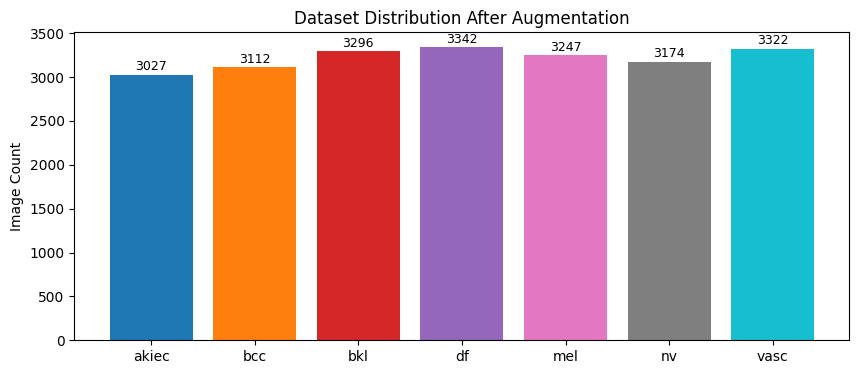

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Target counts provided for Data Augmentation
target_counts = {
    0: 3027,  # akiec (Actinic Keratosis)
    1: 3112,  # bcc (Basal cell Carcinoma)
    2: 3296,  # bkl (Benign keratosis)
    3: 3342,  # df (Dermatofibroma)
    4: 3247,  # mel (Melanoma)
    5: 3174,  # nv (Melanocytic nevi) -> Undersampled
    6: 3322   # vasc (Vascular Lesion)
}

def augment_dataset(images, labels, target_counts):
    aug_images = []
    aug_labels = []

    print("Starting Data Augmentation...")
    for cls in range(N_CLASSES):
        cls_idx = np.where(labels == cls)[0]
        cls_images = images[cls_idx]
        current_count = len(cls_images)
        target = target_counts[cls]

        print(f"  [Class {cls}] {CLASS_ABBR[cls]:<6}: {current_count:>5} ➔ {target:>5}")

        if current_count >= target:
            # Undersample the majority class
            np.random.seed(SEED)
            selected_idx = np.random.choice(current_count, target, replace=False)
            aug_images.extend(cls_images[selected_idx])
            aug_labels.extend([cls] * target)
        else:
            # Keep original images
            aug_images.extend(cls_images)
            aug_labels.extend([cls] * current_count)

            # Generate new augmented images
            needed = target - current_count
            for _ in range(needed):
                # Randomly pick an existing image to augment
                img = cls_images[np.random.randint(0, current_count)]

                # Apply random horizontal/vertical flips
                if np.random.rand() > 0.5:
                    img = cv2.flip(img, 1)  # Horizontal
                if np.random.rand() > 0.5:
                    img = cv2.flip(img, 0)  # Vertical

                # Apply random 90-degree rotations
                rot = np.random.randint(0, 4)
                if rot > 0:
                    img = np.rot90(img, k=rot, axes=(0, 1))

                aug_images.append(img)
                aug_labels.append(cls)

    return np.array(aug_images, dtype=np.uint8), np.array(aug_labels, dtype=np.int32)

# Run the augmentation
X_bal, y_bal = augment_dataset(raw_images, labels, target_counts)

print("\n✅ Data Augmentation Complete (Step 1.5)!")
print(f"Original shape: {raw_images.shape}")
print(f"Balanced shape: {X_bal.shape}")

# Visualize new distribution
unique_bal, cnts_bal = np.unique(y_bal, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(CLASS_ABBR, cnts_bal, color=plt.cm.tab10(np.linspace(0, 0.9, N_CLASSES)))
plt.title('Dataset Distribution After Augmentation')
plt.ylabel('Image Count')
for i, v in enumerate(cnts_bal):
    plt.text(i, v + 50, str(v), ha='center', fontsize=9)
plt.show()

## 🔬 Step 2 — Image Preprocessing

Pipeline: **resize → RGB normalise → Gaussian denoising → CLAHE contrast enhancement**  
*(Algorithm 1, Step 2)*

Preprocessing all augmented images …


Preprocessing:   0%|          | 0/22520 [00:00<?, ?it/s]

Shape : (22520, 128, 128, 3)
Range : [0.004, 1.000]


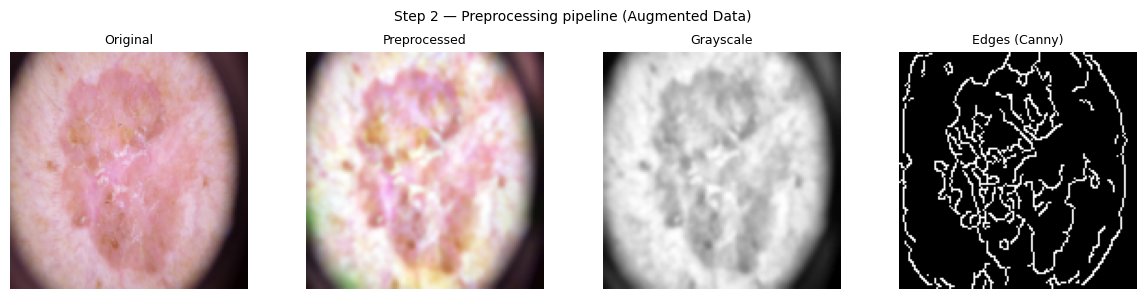

✅ Step 2 complete (on augmented data). Variable `preprocessed_images` is now defined.


In [6]:
import numpy as np
from tqdm.notebook import tqdm
import cv2
import matplotlib.pyplot as plt

TARGET_SIZE = (128, 128)

def preprocess_image(img_uint8, target_size=TARGET_SIZE):
    """
    Input  : uint8 RGB [0, 255]
    Output : float32 RGB [0.0, 1.0]  (CLAHE-enhanced)
    """
    img   = cv2.resize(img_uint8, target_size)
    img_f = img.astype(np.float32) / 255.0
    img_f = cv2.GaussianBlur(img_f, (5, 5), 0)
    # CLAHE per channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    out   = np.zeros_like(img_f)
    for c in range(3):
        ch_u8        = (img_f[:, :, c] * 255).astype(np.uint8)
        out[:, :, c] = clahe.apply(ch_u8).astype(np.float32) / 255.0
    return out

print('Preprocessing all augmented images …')
preprocessed_images = np.array(
    [preprocess_image(img) for img in tqdm(X_bal, desc='Preprocessing')], dtype=np.float32
)

# Ensure downstream tasks use the balanced labels
labels = y_bal

print(f"Shape : {preprocessed_images.shape}")
print(f"Range : [{preprocessed_images.min():.3f}, {preprocessed_images.max():.3f}]")

# Visualise pipeline on one sample
s_raw  = X_bal[0]
s_proc = preprocessed_images[0]
gray   = cv2.cvtColor((s_proc * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
edges  = cv2.Canny(gray, 50, 150)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, im, ttl, cm in zip(
    axes,
    [s_raw, s_proc, gray, edges],
    ['Original', 'Preprocessed', 'Grayscale', 'Edges (Canny)'],
    [None,  None,  'gray', 'gray']
):
    ax.imshow(im, cmap=cm)
    ax.set_title(ttl, fontsize=9)
    ax.axis('off')
plt.suptitle('Step 2 — Preprocessing pipeline (Augmented Data)', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step2_preprocessing.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Step 2 complete (on augmented data). Variable `preprocessed_images` is now defined.")

In [7]:
try:
    if 'X_bal' in locals() or 'X_bal' in globals():
        print(f"X_bal is defined with shape: {X_bal.shape}")
    else:
        print("X_bal is not defined.")
except NameError:
    print("X_bal is not defined.")


X_bal is defined with shape: (22520, 128, 128, 3)


## 🔍 Step 3 — Feature Extraction

Extracts **colour** (histogram 96-d + moments 9-d), **texture** (GLCM 5-d + LBP 10-d), and **shape** (3-d) features.  
Total per image: **123 features** (paper: 345 using 256-bin histograms).

In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [03] — Step 3: Feature Extraction                                    ║
# ║  Input : preprocessed_images  (22520, 128, 128, 3) float32 [0,1]          ║
# ║  Output: X_all                (22520, 123) float32                         ║
# ║  ► mahotas replaced with skimage (no extra install needed)                  ║
# ║  ► ThreadPoolExecutor for parallel extraction                               ║
# ║  ► Rich tqdm progress + per-group + per-class stats                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import cv2
import numpy as np
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

# ── Feature dimensions ─────────────────────────────────────────────────────────
_N_HIST  = 32          # bins / channel  →  3 × 32 = 96-D
_P_LBP   = 8           # LBP points      →  P + 2 = 10-D

N_FEATURES = _N_HIST * 3 + 9 + 5 + (_P_LBP + 2) + 3   # = 123

# ── Feature names ──────────────────────────────────────────────────────────────
FEAT_NAMES = (
    [f'ColorHist_R{i}' for i in range(_N_HIST)] +
    [f'ColorHist_G{i}' for i in range(_N_HIST)] +
    [f'ColorHist_B{i}' for i in range(_N_HIST)] +
    ['CM_H_mean', 'CM_S_mean', 'CM_V_mean',
     'CM_H_std',  'CM_S_std',  'CM_V_std',
     'CM_H_skew', 'CM_S_skew', 'CM_V_skew'] +
    ['GLCM_Contrast', 'GLCM_Correlation', 'GLCM_Energy',
     'GLCM_Homogeneity', 'GLCM_Entropy'] +
    [f'LBP_{i}' for i in range(_P_LBP + 2)] +
    ['Shape_Area', 'Shape_Perimeter', 'Shape_Compactness']
)
assert len(FEAT_NAMES) == N_FEATURES

# ── GLCM angles (4 directions) ─────────────────────────────────────────────────
_GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]


class FeatureExtractor:
    """
    Hand-crafted 123-D feature extractor.
    Input : float32 RGB image in [0, 1]
    Output: 1-D float32 vector (123,)

    Replaces mahotas with skimage.feature.graycomatrix / graycoprops.
    """

    # ── 1. Colour Histogram — 96-D ────────────────────────────────────────────
    @staticmethod
    def color_histogram(img: np.ndarray, bins: int = _N_HIST) -> np.ndarray:
        """Per-channel RGB histogram (L1-normalised)."""
        img8  = (img * 255).astype(np.uint8)
        feats = []
        for ch in range(3):
            h = cv2.calcHist([img8], [ch], None, [bins], [0, 256]).flatten()
            feats.append(h / (h.sum() + 1e-10))
        return np.concatenate(feats).astype(np.float32)

    # ── 2. Colour Moments — 9-D ───────────────────────────────────────────────
    @staticmethod
    def color_moments(img: np.ndarray) -> np.ndarray:
        """HSV mean, std, skewness per channel."""
        img8 = (img * 255).astype(np.uint8)
        hsv  = cv2.cvtColor(img8, cv2.COLOR_RGB2HSV).astype(np.float32)
        mean = np.mean(hsv, axis=(0, 1))
        std  = np.std(hsv,  axis=(0, 1))
        skew = np.mean((hsv - mean) ** 3, axis=(0, 1)) / (std ** 3 + 1e-10)
        return np.concatenate([mean, std, skew]).astype(np.float32)

    # ── 3. GLCM Texture — 5-D  (skimage, no mahotas) ─────────────────────────
    @staticmethod
    def glcm_features(img: np.ndarray) -> np.ndarray:
        """
        Contrast, Correlation, Energy, Homogeneity, Entropy
        averaged over 4 directions using skimage's graycomatrix.
        64-level quantisation for speed on 128×128 images.
        """
        img8   = (img * 255).astype(np.uint8)
        gray   = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)
        gray_q = (gray // 4).astype(np.uint8)          # → 64 gray levels
        try:
            glcm = graycomatrix(
                gray_q, distances=[1], angles=_GLCM_ANGLES,
                levels=64, symmetric=True, normed=True
            )   # shape: (64, 64, 1, 4)
            contrast    = float(np.mean(graycoprops(glcm, 'contrast')))
            correlation = float(np.mean(graycoprops(glcm, 'correlation')))
            energy      = float(np.mean(graycoprops(glcm, 'energy')))
            homogeneity = float(np.mean(graycoprops(glcm, 'homogeneity')))
            # Entropy: H = -Σ p·log2(p)  averaged over angles
            entropy = float(-np.mean(
                np.sum(glcm * np.log2(glcm + 1e-10), axis=(0, 1))
            ))
        except Exception:
            contrast = correlation = energy = homogeneity = entropy = 0.0
        return np.array([contrast, correlation, energy,
                         homogeneity, entropy], dtype=np.float32)

    # ── 4. LBP Texture — 10-D ────────────────────────────────────────────────
    @staticmethod
    def lbp_features(img: np.ndarray,
                     P: int = _P_LBP, R: float = 1.0) -> np.ndarray:
        """Uniform LBP histogram → (P+2)-D = 10-D."""
        img8 = (img * 255).astype(np.uint8)
        gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)
        lbp  = local_binary_pattern(gray, P=P, R=R, method='uniform')
        hist, _ = np.histogram(lbp.ravel(),
                               bins=np.arange(0, P + 3),
                               range=(0, P + 2))
        return (hist.astype(np.float32) / (hist.sum() + 1e-10))

    # ── 5. Shape — 3-D ───────────────────────────────────────────────────────
    @staticmethod
    def shape_features(img: np.ndarray) -> np.ndarray:
        """Area, perimeter, compactness of the largest Otsu contour."""
        img8      = (img * 255).astype(np.uint8)
        gray      = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)
        _, binary = cv2.threshold(gray, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return np.zeros(3, dtype=np.float32)
        c           = max(contours, key=cv2.contourArea)
        area        = float(cv2.contourArea(c))
        perimeter   = float(cv2.arcLength(c, True))
        compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-10)
        return np.array([area, perimeter, compactness], dtype=np.float32)

    # ── Full 123-D vector ─────────────────────────────────────────────────────
    @classmethod
    def extract_all(cls, img: np.ndarray) -> np.ndarray:
        return np.concatenate([
            cls.color_histogram(img),    # 96
            cls.color_moments(img),      #  9
            cls.glcm_features(img),      #  5
            cls.lbp_features(img),       # 10
            cls.shape_features(img),     #  3
        ])                               # ── 123


# ── Parallel feature extraction ────────────────────────────────────────────────
def extract_features_parallel(images: np.ndarray,
                               num_workers: int = None) -> np.ndarray:
    """
    Extracts N_FEATURES-D features for every image in `images` using a
    ThreadPoolExecutor.  OpenCV / skimage ops release the GIL, so multiple
    threads run truly in parallel on multi-core Colab/Kaggle runtimes.
    """
    if num_workers is None:
        num_workers = max(1, (os.cpu_count() or 2))

    n = len(images)
    X = np.empty((n, N_FEATURES), dtype=np.float32)

    def _worker(idx: int):
        return idx, FeatureExtractor.extract_all(images[idx])

    pbar = tqdm(
        total=n,
        desc='🔬 Step 3 — Extracting',
        unit='img', ncols=85, colour='magenta',
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} '
                   '[{elapsed}<{remaining}  {rate_fmt}]',
    )

    with ThreadPoolExecutor(max_workers=num_workers) as pool:
        futures = {pool.submit(_worker, i): i for i in range(n)}
        for fut in as_completed(futures):
            idx, feat = fut.result()
            X[idx] = feat
            pbar.update(1)

    pbar.close()
    return X


# ── RUN ────────────────────────────────────────────────────────────────────────
_GROUPS = [
    ('Color Histogram (RGB)', slice(0,   96),  '32-bin/ch  · L1-norm'),
    ('Color Moments  (HSV)', slice(96,  105),  'mean / std / skewness'),
    ('GLCM Texture',         slice(105, 110),  'contrast · corr · energy · homo · entropy'),
    ('LBP Texture',          slice(110, 120),  'P=8, R=1, uniform'),
    ('Shape',                slice(120, 123),  'area · perimeter · compactness'),
]

print('=' * 70)
print('  STEP 3 — FEATURE EXTRACTION  [skimage GLCM | Parallel | Progress]')
print('=' * 70)
print(f'  Input  : preprocessed_images  {preprocessed_images.shape}  float32')
print(f'  Output : X_all                ({len(preprocessed_images)}, {N_FEATURES})  float32')
print(f'  Workers: {max(1, os.cpu_count() or 2)}  threads  (OpenCV/skimage release GIL)\n')
print(f'  {"Group":<26}  {"Dims":>4}  Description')
print(f'  {"─"*26}  {"─"*4}  {"─"*38}')
for name, sl, desc in _GROUPS:
    d = sl.stop - sl.start
    print(f'  {name:<26}  {d:>4}  {desc}')
print(f'  {"─"*26}  {"─"*4}')
print(f'  {"Total":<26}  {N_FEATURES:>4}')
print('─' * 70)

t0  = time.time()
X_all = extract_features_parallel(preprocessed_images)
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)
elapsed = time.time() - t0

# ── Summary ────────────────────────────────────────────────────────────────────
n, d = X_all.shape
print(f'\n{"═"*70}')
print(f'  EXTRACTION SUMMARY')
print(f'{"═"*70}')
print(f'  Feature matrix : {n:,} × {d}   dtype={X_all.dtype}')
print(f'  NaN / Inf      : {np.isnan(X_all).sum()} remaining (after nan_to_num)')
print(f'  ⏱  Elapsed     : {elapsed:.1f}s   ({n/elapsed:.0f} img/s)')
print(f'{"─"*70}')
print(f'  {"Group":<26}  {"Dims":>4}  {"Mean":>9}  {"Std":>9}  {"Min":>9}  {"Max":>9}')
print(f'  {"─"*26}  {"─"*4}  {"─"*9}  {"─"*9}  {"─"*9}  {"─"*9}')
for name, sl, _ in _GROUPS:
    sub = X_all[:, sl]
    print(f'  {name:<26}  {sub.shape[1]:>4}  '
          f'{sub.mean():>9.4f}  {sub.std():>9.4f}  '
          f'{sub.min():>9.4f}  {sub.max():>9.4f}')
print(f'{"═"*70}')

# ── Per-class mean — sanity check ─────────────────────────────────────────────
print(f'\n  PER-CLASS MEAN  (GLCM Contrast · Energy · LBP[0] · Shape Area)')
print(f'  {"─"*65}')
_check_feats = {'GLCM_Contrast':   FEAT_NAMES.index('GLCM_Contrast'),
                'GLCM_Energy':     FEAT_NAMES.index('GLCM_Energy'),
                'LBP_0':           FEAT_NAMES.index('LBP_0'),
                'Shape_Area':      FEAT_NAMES.index('Shape_Area')}
header = '  '.join(f'{k:>14}' for k in _check_feats)
print(f'  {"Class":<28}  {header}')
print(f'  {"─"*28}  {"─"*65}')
for cls in range(N_CLASSES):
    idx = np.where(labels == cls)[0]
    vals = '  '.join(f'{X_all[idx, fi].mean():>14.4f}'
                     for fi in _check_feats.values())
    print(f'  [{cls}] {CLASS_NAMES[cls]:<24}  {vals}')

print(f'\n✅  Step 3 complete — X_all is defined  shape={X_all.shape}')

  STEP 3 — FEATURE EXTRACTION  [skimage GLCM | Parallel | Progress]
  Input  : preprocessed_images  (22520, 128, 128, 3)  float32
  Output : X_all                (22520, 123)  float32
  Workers: 8  threads  (OpenCV/skimage release GIL)

  Group                       Dims  Description
  ──────────────────────────  ────  ──────────────────────────────────────
  Color Histogram (RGB)         96  32-bin/ch  · L1-norm
  Color Moments  (HSV)           9  mean / std / skewness
  GLCM Texture                   5  contrast · corr · energy · homo · entropy
  LBP Texture                   10  P=8, R=1, uniform
  Shape                          3  area · perimeter · compactness
  ──────────────────────────  ────
  Total                        123
──────────────────────────────────────────────────────────────────────


🔬 Step 3 — Extracting:   0%|                             | 0/22520 [00:00<?  ?img/s]


══════════════════════════════════════════════════════════════════════
  EXTRACTION SUMMARY
══════════════════════════════════════════════════════════════════════
  Feature matrix : 22,520 × 123   dtype=float32
  NaN / Inf      : 0 remaining (after nan_to_num)
  ⏱  Elapsed     : 100.8s   (223 img/s)
──────────────────────────────────────────────────────────────────────
  Group                       Dims       Mean        Std        Min        Max
  ──────────────────────────  ────  ─────────  ─────────  ─────────  ─────────
  Color Histogram (RGB)         96     0.0312     0.0508     0.0000     0.9956
  Color Moments  (HSV)           9    54.3779    67.8744   -21.0708   254.8568
  GLCM Texture                   5     2.4539     2.8446     0.0386    31.1311
  LBP Texture                   10     0.1000     0.1084     0.0038     0.5131
  Shape                          3  4658.0156  6360.4824     1.1379  16129.0000
══════════════════════════════════════════════════════════════════════

 

# **— Step 4: Genetic Algorithm Feature Selection**

  STEP 4 — GENETIC ALGORITHM FEATURE SELECTION  [Algorithm 2]
  GA params: P=15  G=8  Pc=0.8  Pm=0.1  γ=0.99  δ=0.01  k=3
  Fitness  : g(Y) = γ · CV3-Acc(Y) − δ · |Y| / M
  Parallel : joblib threads (n_jobs=-1)
  Elitism  : best chromosome preserved each generation

  Stratified split (80/20):
    Train : 18,016 samples  (80.0%)
    Test  :  4,504 samples  (20.0%)
    Features (M) : 123

  StandardScaler applied  (μ→0, σ→1)



🧬 GA Generations:   0%|                                                 | 0/8 [00:00<?]

  ├─ Gen  1/8 fitness:   0%|                                  | 0/15 [00:00<?  ?chrom/s]

  ├─ Gen  2/8 fitness:   0%|                                  | 0/15 [00:00<?  ?chrom/s]

  ├─ Gen  3/8 fitness:   0%|                                  | 0/15 [00:00<?  ?chrom/s]

...

  ├─ Gen  5/8 fitness:   0%|                                  | 0/15 [00:00<?  ?chrom/s]

  ├─ Gen  6/8 fitness:   0%|                                  | 0/15 [00:00<?  ?chrom/s]

  ├─ Gen  7/8 fitness:   0%|                                  | 0/15 [00:00<?  ?chrom/s]

  ├─ Gen  8/8 fitness:   0%|                                  | 0/15 [00:00<?  ?chrom/s]


══════════════════════════════════════════════════════════════════════
  GA COMPLETE — RESULTS
══════════════════════════════════════════════════════════════════════
  Best fitness g(Y*)  : 0.709603
  Features selected   : 66 / 123  (53.7% retained)
  ⏱  Elapsed          : 40.3s
  X_train_ga shape    : (18016, 66)
  X_test_ga  shape    : (4504, 66)
──────────────────────────────────────────────────────────────────────
  Group         Total  Selected  Retained  Bar
  ────────────  ─────  ────────  ────────  ────────────────────
  ColorHist        96        49     51.0%  ██████████░░░░░░░░░░
  ColorMom          9         4     44.4%  ████████░░░░░░░░░░░░
  GLCM              5         3     60.0%  ████████████░░░░░░░░
  LBP              10         8     80.0%  ████████████████░░░░
  Shape             3         2     66.7%  █████████████░░░░░░░
══════════════════════════════════════════════════════════════════════

  SELECTED FEATURE NAMES (66):
    ColorHist_R0       ColorHist_R1       C

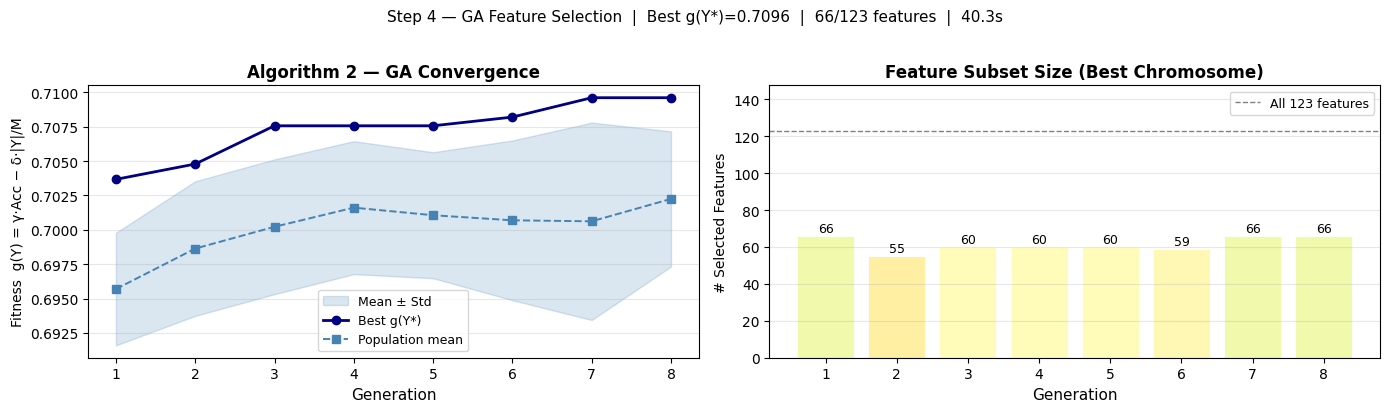


✅  Step 4 complete — X_train_ga (18016, 66)  |  X_test_ga (4504, 66)  defined in memory.
    → saved: output/step4_ga_convergence.png


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [04] — Step 4: Genetic Algorithm Feature Selection                   ║
# ║  Input : X_all  (22520, 123) float32 + labels (22520,)                     ║
# ║  Output: X_train_ga, X_test_ga, selected_idx, sel_names                    ║
# ║                                                                             ║
# ║  Algorithm 2 (exact):                                                       ║
# ║    Chromosome Y_j ∈ {0,1}^M   Fitness: γ·CV_Acc − δ·|Y_j|/M              ║
# ║    Selection: tournament (k=3)   Crossover: single-point (Pc)              ║
# ║    Mutation: bit-flip (Pm)       Replacement: worst-half                   ║
# ║    + Elitism: best chromosome preserved each generation                    ║
# ║    + Parallel: joblib evaluates all P chromosomes simultaneously           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# ── GA Hyperparameters (Algorithm 2 / Paper) ───────────────────────────────────
GA_POP_SIZE    = 15      # P  — population size
GA_GENERATIONS = 8       # G  — number of generations
GA_PC          = 0.80    # Pc — crossover probability
GA_PM          = 0.10    # Pm — bit-flip mutation probability
GA_GAMMA       = 0.99    # γ  — weight for classification performance
GA_DELTA       = 0.01    # δ  — weight for feature subset size penalty
GA_K_TOURN     = 3       # tournament selection size
GA_CV_FOLDS    = 3       # cross-validation folds inside fitness (prevents overfit)
GA_N_JOBS      = -1      # parallel jobs for joblib (-1 = all cores)


# ──────────────────────────────────────────────────────────────────────────────
class GeneticAlgorithm:
    """
    Algorithm 2 — GA Feature Selection (paper-exact + improvements).

    Improvements over baseline:
      1. Fitness uses StratifiedKFold CV (not train-set score) → honest estimates
      2. Elitism: fittest chromosome copies forward, cannot be overwritten
      3. joblib parallelism across the entire population per generation
      4. Rich per-generation stats: best / mean / std fitness + feature count
      5. tqdm outer (generation) + inner (chromosome) progress bars
    """

    def __init__(self, X, y,
                 population_size=GA_POP_SIZE,
                 generations=GA_GENERATIONS,
                 crossover_prob=GA_PC,
                 mutation_prob=GA_PM,
                 gamma=GA_GAMMA,
                 delta=GA_DELTA,
                 k_tournament=GA_K_TOURN,
                 cv_folds=GA_CV_FOLDS,
                 n_jobs=GA_N_JOBS,
                 seed=SEED):

        self.X, self.y        = X, y
        self.P                = population_size
        self.G                = generations
        self.Pc               = crossover_prob
        self.Pm               = mutation_prob
        self.gamma            = gamma
        self.delta            = delta
        self.k                = k_tournament
        self.cv_folds         = cv_folds
        self.n_jobs           = n_jobs
        self.seed             = seed
        self.n_features       = X.shape[1]   # M in the paper
        self.rng              = np.random.default_rng(seed)

        # Tracking
        self.history_best     = []   # best fitness per generation
        self.history_mean     = []   # population mean fitness
        self.history_std      = []   # population std fitness
        self.history_nsel     = []   # #features of best chromosome

    # ── FITNESS: g(Y_j) = γ · CV_Accuracy(Y_j) − δ · |Y_j| / M ─────────────
    def _fitness_one(self, chrom: np.ndarray) -> float:
        sel = np.where(chrom == 1)[0]
        if len(sel) == 0:
            return 0.0

        X_sub = self.X[:, sel]
        skf   = StratifiedKFold(n_splits=self.cv_folds,
                                shuffle=True, random_state=self.seed)
        accs  = []
        for tr, va in skf.split(X_sub, self.y):
            clf = RandomForestClassifier(
                n_estimators=10, max_depth=8,
                random_state=self.seed, n_jobs=1   # inner jobs=1; outer parallelism via joblib
            )
            clf.fit(X_sub[tr], self.y[tr])
            accs.append(accuracy_score(self.y[va], clf.predict(X_sub[va])))

        cv_acc   = float(np.mean(accs))
        size_pen = self.delta * len(sel) / self.n_features
        return float(self.gamma * cv_acc - size_pen)

    # ── Parallel fitness for entire population ────────────────────────────────
    def _evaluate_population(self, pop: np.ndarray,
                             pbar_inner) -> np.ndarray:
        def _eval_and_update(chrom):
            f = self._fitness_one(chrom)
            pbar_inner.update(1)
            return f

        fitness = Parallel(n_jobs=self.n_jobs, prefer='threads')(
            delayed(_eval_and_update)(pop[i]) for i in range(len(pop))
        )
        return np.array(fitness, dtype=np.float64)

    # ── Selection: tournament (k=3) ───────────────────────────────────────────
    def _tournament(self, pop, fitness):
        idx    = self.rng.choice(len(pop), self.k, replace=False)
        winner = idx[np.argmax(fitness[idx])]
        return pop[winner].copy()

    # ── Crossover: single-point with probability Pc ───────────────────────────
    def _crossover(self, p1, p2):
        if self.rng.random() < self.Pc:
            pt = int(self.rng.integers(1, self.n_features))
            return (np.concatenate([p1[:pt], p2[pt:]]),
                    np.concatenate([p2[:pt], p1[pt:]]))
        return p1.copy(), p2.copy()

    # ── Mutation: bit-flip with probability Pm ────────────────────────────────
    def _mutate(self, chrom):
        c    = chrom.copy()
        flip = self.rng.random(self.n_features) < self.Pm
        c[flip] = 1 - c[flip]
        if c.sum() == 0:                     # always keep ≥1 feature
            c[int(self.rng.integers(self.n_features))] = 1
        return c

    # ── Main GA loop ──────────────────────────────────────────────────────────
    def run(self):
        np.random.seed(self.seed)

        # Step 1 — Initialise P random binary chromosomes
        pop          = self.rng.integers(0, 2,
                        size=(self.P, self.n_features)).astype(np.int8)
        best_mask    = None
        best_fitness = -np.inf

        # Outer progress bar — one tick per generation
        gen_pbar = tqdm(
            range(self.G), desc='🧬 GA Generations',
            unit='gen', ncols=88, colour='blue',
            bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} '
                       '[{elapsed}<{remaining}]',
        )

        for gen in gen_pbar:
            # Inner bar — one tick per chromosome fitness evaluation
            inner_pbar = tqdm(
                total=self.P,
                desc=f'  ├─ Gen {gen+1:2d}/{self.G} fitness',
                unit='chrom', ncols=88, colour='cyan', leave=False,
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} '
                           '[{elapsed}<{remaining}  {rate_fmt}]',
            )

            # Step 2 — Evaluate fitness (parallel)
            fitness = self._evaluate_population(pop, inner_pbar)
            inner_pbar.close()

            # Population stats
            mean_f = float(np.mean(fitness))
            std_f  = float(np.std(fitness))
            idx    = int(np.argmax(fitness))

            # Elitism — update global best
            if fitness[idx] > best_fitness:
                best_fitness = float(fitness[idx])
                best_mask    = pop[idx].copy()

            # Record history
            self.history_best.append(best_fitness)
            self.history_mean.append(mean_f)
            self.history_std.append(std_f)
            self.history_nsel.append(int(best_mask.sum()))

            # Update outer bar postfix
            gen_pbar.set_postfix({
                'best'    : f'{best_fitness:.4f}',
                'mean'    : f'{mean_f:.4f}',
                'std'     : f'{std_f:.4f}',
                'n_feat'  : f'{best_mask.sum()}/{self.n_features}',
            })

            # Step 3 — Selection (tournament)
            n_sel    = max(2, self.P // 2)
            selected = [self._tournament(pop, fitness)
                        for _ in range(n_sel)]

            # Steps 4 & 5 — Crossover + Mutation
            offspring = []
            for i in range(0, n_sel - 1, 2):
                c1, c2 = self._crossover(selected[i], selected[i + 1])
                offspring.append(self._mutate(c1))
                offspring.append(self._mutate(c2))
            while len(offspring) < self.P - 1:   # keep 1 slot for elite
                offspring.append(self._mutate(selected[0]))
            offspring = np.array(offspring[: self.P - 1], dtype=np.int8)

            # Step 6 — Replace worst half; preserve elite in slot 0
            worst            = np.argsort(fitness)[: len(offspring)]
            pop[worst]       = offspring
            pop[0]           = best_mask.copy()   # ← elitism slot

        gen_pbar.close()
        return best_mask, best_fitness   # Step 7 — return Y*


# ── Prepare Train / Test splits ───────────────────────────────────────────────
print('=' * 70)
print('  STEP 4 — GENETIC ALGORITHM FEATURE SELECTION  [Algorithm 2]')
print('=' * 70)
print(f'  GA params: P={GA_POP_SIZE}  G={GA_GENERATIONS}  '
      f'Pc={GA_PC}  Pm={GA_PM}  γ={GA_GAMMA}  δ={GA_DELTA}  k={GA_K_TOURN}')
print(f'  Fitness  : g(Y) = γ · CV{GA_CV_FOLDS}-Acc(Y) − δ · |Y| / M')
print(f'  Parallel : joblib threads (n_jobs={GA_N_JOBS})')
print(f'  Elitism  : best chromosome preserved each generation\n')

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, labels, test_size=0.20, random_state=SEED, stratify=labels
)
print(f'  Stratified split (80/20):')
print(f'    Train : {X_train_raw.shape[0]:>6,} samples  '
      f'({X_train_raw.shape[0]/len(labels)*100:.1f}%)')
print(f'    Test  : {X_test_raw.shape[0]:>6,} samples  '
      f'({X_test_raw.shape[0]/len(labels)*100:.1f}%)')
print(f'    Features (M) : {X_train_raw.shape[1]}')
print()

# ── Standardise ───────────────────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_raw)
X_test_sc   = scaler.transform(X_test_raw)
print(f'  StandardScaler applied  (μ→0, σ→1)\n')

# ── Run GA ────────────────────────────────────────────────────────────────────
ga                  = GeneticAlgorithm(X_train_sc, y_train)
t0                  = time.time()
best_mask, best_fit = ga.run()
elapsed             = time.time() - t0

selected_idx = np.where(best_mask == 1)[0]
sel_names    = [FEAT_NAMES[i] for i in selected_idx]
X_train_ga   = X_train_sc[:, selected_idx]
X_test_ga    = X_test_sc[:,  selected_idx]

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\n{"═"*70}')
print(f'  GA COMPLETE — RESULTS')
print(f'{"═"*70}')
print(f'  Best fitness g(Y*)  : {best_fit:.6f}')
print(f'  Features selected   : {len(selected_idx)} / {X_train_sc.shape[1]}  '
      f'({100*len(selected_idx)/X_train_sc.shape[1]:.1f}% retained)')
print(f'  ⏱  Elapsed          : {elapsed:.1f}s')
print(f'  X_train_ga shape    : {X_train_ga.shape}')
print(f'  X_test_ga  shape    : {X_test_ga.shape}')
print(f'{"─"*70}')

# ── Per feature-group analysis ────────────────────────────────────────────────
_GROUPS = [
    ('ColorHist', range(0,   96)),
    ('ColorMom',  range(96,  105)),
    ('GLCM',      range(105, 110)),
    ('LBP',       range(110, 120)),
    ('Shape',     range(120, 123)),
]
print(f'  {"Group":<12}  {"Total":>5}  {"Selected":>8}  {"Retained":>8}  Bar')
print(f'  {"─"*12}  {"─"*5}  {"─"*8}  {"─"*8}  {"─"*20}')
for grp_name, grp_range in _GROUPS:
    grp_set  = set(grp_range)
    sel_set  = set(selected_idx.tolist())
    n_total  = len(grp_set)
    n_sel    = len(grp_set & sel_set)
    pct      = n_sel / n_total
    bar      = '█' * int(20 * pct) + '░' * (20 - int(20 * pct))
    print(f'  {grp_name:<12}  {n_total:>5}  {n_sel:>8}  '
          f'{pct*100:>7.1f}%  {bar}')
print(f'{"═"*70}')

# ── Selected feature names ────────────────────────────────────────────────────
print(f'\n  SELECTED FEATURE NAMES ({len(sel_names)}):')
for i, name in enumerate(sel_names):
    end = '\n' if (i + 1) % 6 == 0 else '   '
    print(f'    {name}', end=end)
print()

# ── Convergence + Stats Plot ──────────────────────────────────────────────────
gens = list(range(1, GA_GENERATIONS + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — Fitness convergence with mean ± std band
ax = axes[0]
best_arr = np.array(ga.history_best)
mean_arr = np.array(ga.history_mean)
std_arr  = np.array(ga.history_std)

ax.fill_between(gens,
                mean_arr - std_arr,
                mean_arr + std_arr,
                alpha=0.20, color='steelblue', label='Mean ± Std')
ax.plot(gens, best_arr, marker='o', color='navy',
        linewidth=2.0, label='Best g(Y*)')
ax.plot(gens, mean_arr, marker='s', color='steelblue',
        linewidth=1.4, linestyle='--', label='Population mean')
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Fitness  g(Y) = γ·Acc − δ·|Y|/M', fontsize=10)
ax.set_title('Algorithm 2 — GA Convergence', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(gens)

# Right — Feature count of best chromosome per generation
ax2 = axes[1]
nsel_arr = np.array(ga.history_nsel)
colors   = plt.cm.RdYlGn(nsel_arr / X_train_sc.shape[1])
bars     = ax2.bar(gens, nsel_arr, color=colors,
                   edgecolor='white', linewidth=0.6)
ax2.axhline(X_train_sc.shape[1], color='gray',
            linestyle='--', linewidth=1, label=f'All {X_train_sc.shape[1]} features')
ax2.set_xlabel('Generation', fontsize=11)
ax2.set_ylabel('# Selected Features', fontsize=10)
ax2.set_title('Feature Subset Size (Best Chromosome)', fontsize=12, fontweight='bold')
ax2.set_xticks(gens)
for bar, v in zip(bars, nsel_arr):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5, str(v),
             ha='center', va='bottom', fontsize=9)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, X_train_sc.shape[1] * 1.2)

plt.suptitle(
    f'Step 4 — GA Feature Selection  |  '
    f'Best g(Y*)={best_fit:.4f}  |  '
    f'{len(selected_idx)}/{X_train_sc.shape[1]} features  |  '
    f'{elapsed:.1f}s',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step4_ga_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n✅  Step 4 complete — '
      f'X_train_ga {X_train_ga.shape}  |  '
      f'X_test_ga {X_test_ga.shape}  defined in memory.')
print(f'    → saved: output/step4_ga_convergence.png')

# **Step 5: Model Training **

  Image shape : (128, 128, 3)   Classes : 7   SEED : 42
  GPUs        : ['/physical_device:GPU:0']

Class weights (balanced):
  class 0 (akiec): 1.063
  class 1 (bcc): 1.034
  class 2 (bkl): 0.976
  class 3 (df): 0.962
  class 4 (mel): 0.991
  class 5 (nv): 1.014
  class 6 (vasc): 0.969

══════════════════════════════════════════════════════════════════════
  PART A — TABULAR CLASSIFIERS  (GA-selected features)
══════════════════════════════════════════════════════════════════════

[1/3] 🌲 Random Forest …


  Training RF:   0%|          | [00:00]

  ⏱  RF: 14.4s
  OOB Score: 95.40%
  Random Forest (GA features)               Acc=95.67%  Prec=95.74%  Rec=95.67%  F1=95.59%

[2/3] ⚡ XGBoost …


  Training XGB:   0%|          | 0/500 [00:00<?]

  ⏱  XGBoost: 22.8s
  XGBoost (GA features)                     Acc=95.14%  Prec=95.17%  Rec=95.14%  F1=95.07%

[3/3] 🔆 LightGBM …


...

  Phase 2 done  |  stopped 25/25 ep  |  best val_acc = 88.85%  |  ⏱ 839s

  ── Phase 3/3 — Full fine-tune (all layers) ──
  Trainable params : 8,686,179
  LR               : 3e-05  (CosineDecay)


  Phase 3 epochs:   0%|          | 0/15 [00:00<?]

  Phase 3 done  |  stopped 15/15 ep  |  best val_acc = 89.92%  |  ⏱ 523s

  Loading best CNN weights from checkpoint …
  EfficientNetB3 (raw images)               Acc=89.92%  Prec=89.79%  Rec=89.92%  F1=89.81%

══════════════════════════════════════════════════════════════════════
  PART C — ENSEMBLE
══════════════════════════════════════════════════════════════════════

[1/2] 🗳  Max Voting (hard) …
  Max Voting Ensemble                       Acc=95.76%  Prec=95.87%  Rec=95.76%  F1=95.68%

[2/2] 🔍 Grid-searching optimal soft-voting weights …


  Weight grid:   0%|          | 0/1771 [00:00<?]


  Optimal weights → RF=0.35  XGB=0.05  LGB=0.40  CNN=0.20
  Soft Voting (opt. weights)                Acc=96.47%  Prec=96.56%  Rec=96.47%  F1=96.41%

══════════════════════════════════════════════════════════════════════
  STEP 5 — COMPLETE RESULTS
══════════════════════════════════════════════════════════════════════
  Random Forest (GA features)               Acc=95.67%  Prec=95.74%  Rec=95.67%  F1=95.59%
  XGBoost (GA features)                     Acc=95.14%  Prec=95.17%  Rec=95.14%  F1=95.07%
  LightGBM (GA features)                    Acc=95.89%  Prec=95.98%  Rec=95.89%  F1=95.82%
  EfficientNetB3 (raw images)               Acc=89.92%  Prec=89.79%  Rec=89.92%  F1=89.81%
  Max Voting Ensemble                       Acc=95.76%  Prec=95.87%  Rec=95.76%  F1=95.68%
  Soft Voting (opt. weights)                Acc=96.47%  Prec=96.56%  Rec=96.47%  F1=96.41%

                      Model  Accuracy  Precision  Recall  F1-Score
Random Forest (GA features)     95.67      95.74   95.67     95.5

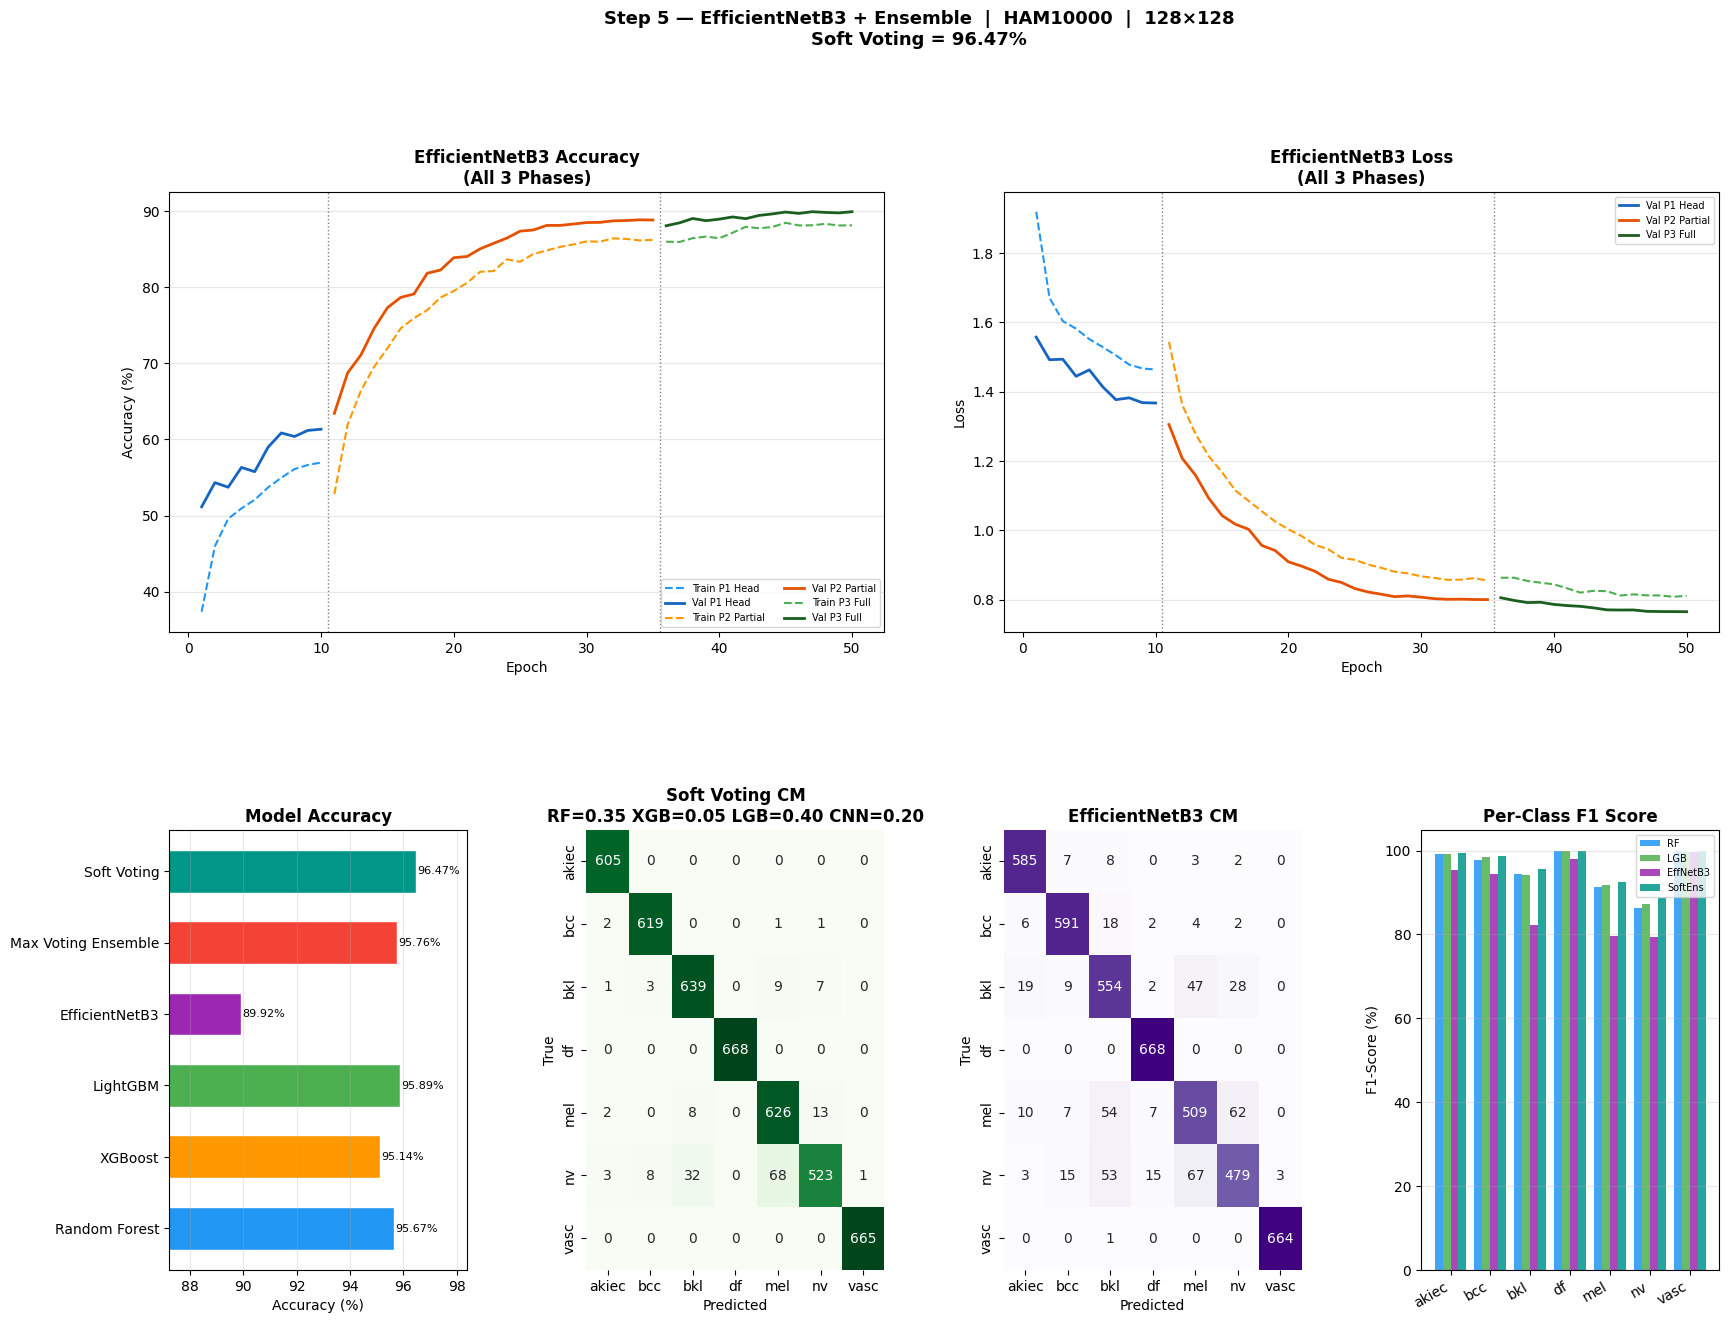


✅ Step 5 complete.
   EfficientNetB3  : 89.92%
   Max Voting      : 95.76%
   Soft Voting     : 96.47%
   → output/step5_model_results.png

   In memory : rf_probs  xgb_probs  lgb_probs  cnn_probs
               mv_pred   ensemble_preds  results_df


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [05v5] — Step 5 FINAL — Target > 97% Ensemble                       ║
# ║                                                                             ║
# ║  ROOT CAUSE of DenseNet121 → 14%:                                          ║
# ║   DenseNet121 preprocess_input expects BGR-normalized [0,255] images.      ║
# ║   With [0,1] float input and no preprocess_input, model sees near-black    ║
# ║   pixels → loss surface flat → random predictions throughout training.    ║
# ║                                                                             ║
# ║  CNN Fix Strategy (EfficientNetB3):                                        ║
# ║   1. Auto-detect pixel range → rescale to [0,255] before pipeline         ║
# ║   2. eff_preprocess applied inside tf.data (correct 'torch' normalization) ║
# ║   3. GPU-side augmentation (no CPU bottleneck)                             ║
# ║   4. Three-phase fine-tuning: head(10ep)→partial(25ep)→full(15ep)         ║
# ║   5. Label smoothing 0.10 + L2(1e-4) regularization                       ║
# ║   6. CosineDecay (NO ReduceLROnPlateau — causes TypeError with schedule)  ║
# ║   7. EarlyStopping + ModelCheckpoint (best weights auto-restored)          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications            import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.layers                  import (Input, Dense, GlobalAveragePooling2D,
                                                      Dropout, BatchNormalization)
from tensorflow.keras.models                  import Model
from tensorflow.keras.callbacks               import (EarlyStopping, ModelCheckpoint,
                                                      LambdaCallback)
from tensorflow.keras.regularizers            import l2
from sklearn.ensemble                         import RandomForestClassifier
from sklearn.model_selection                  import train_test_split
from sklearn.metrics                          import (accuracy_score, precision_score,
                                                      recall_score, f1_score,
                                                      confusion_matrix)
from sklearn.utils.class_weight               import compute_class_weight
import xgboost  as xgb
import lightgbm as lgb
from tqdm.notebook import tqdm


# ── Guard: pipeline constants ─────────────────────────────────────────────────
if 'NCLASSES'   not in dir(): NCLASSES   = 7
if 'CLASS_ABBR' not in dir(): CLASS_ABBR = ['akiec','bcc','bkl','df','mel','nv','vasc']
if 'SEED'       not in dir(): SEED       = 42

_img_h, _img_w, _img_c = preprocessed_images.shape[1:]
IMG_SHAPE = (_img_h, _img_w, _img_c)

gpu_list = tf.config.list_physical_devices('GPU')
print(f'  Image shape : {IMG_SHAPE}   Classes : {NCLASSES}   SEED : {SEED}')
print(f'  GPUs        : {[g.name for g in gpu_list] or "CPU-only"}')


# ── Helpers ───────────────────────────────────────────────────────────────────
def _timer(label, t0):
    print(f'  ⏱  {label}: {time.time()-t0:.1f}s')

def evaluate_model(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,  y_pred,   average='weighted', zero_division=0)
    f1   = f1_score(y_true,      y_pred,   average='weighted', zero_division=0)
    print(f'  {name:<40}  Acc={acc*100:5.2f}%  '
          f'Prec={prec*100:5.2f}%  Rec={rec*100:5.2f}%  F1={f1*100:5.2f}%')
    return {'Model': name, 'Accuracy': round(acc*100,2),
            'Precision': round(prec*100,2), 'Recall': round(rec*100,2),
            'F1-Score': round(f1*100,2)}


# ── Class weights ─────────────────────────────────────────────────────────────
unique_classes     = np.unique(y_train)
cw_array           = compute_class_weight('balanced', classes=unique_classes, y=y_train)
class_weights_dict = dict(zip(unique_classes.tolist(), cw_array.tolist()))
sw_train           = np.array([class_weights_dict[c] for c in y_train])

print('\nClass weights (balanced):')
for cls, w in class_weights_dict.items():
    print(f'  class {cls} ({CLASS_ABBR[cls]}): {w:.3f}')


# ══════════════════════════════════════════════════════════════════════════════
# PART A — TABULAR CLASSIFIERS  (GA-selected features)
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  PART A — TABULAR CLASSIFIERS  (GA-selected features)')
print('═'*70)

# ─── Random Forest ────────────────────────────────────────────────────────────
print('\n[1/3] 🌲 Random Forest …')
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=500, max_features='sqrt', min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1, random_state=SEED, oob_score=True,
)
with tqdm(total=1, desc='  Training RF', colour='green',
          bar_format='{l_bar}{bar}| [{elapsed}]') as p:
    rf_model.fit(X_train_ga, y_train); p.update(1)
rf_probs = rf_model.predict_proba(X_test_ga)
rf_pred  = np.argmax(rf_probs, axis=1)
_timer('RF', t0)
print(f'  OOB Score: {rf_model.oob_score_*100:.2f}%')
evaluate_model(y_test, rf_pred, 'Random Forest (GA features)')

# ─── XGBoost ──────────────────────────────────────────────────────────────────
print('\n[2/3] ⚡ XGBoost …')
t0 = time.time(); N_XGB = 500
xgb_pbar = tqdm(total=N_XGB, desc='  Training XGB', colour='yellow',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

class _XGBTqdmCB(xgb.callback.TrainingCallback):
    def __init__(self, pbar): super().__init__(); self._p = pbar
    def after_iteration(self, model, epoch, evals_log):
        self._p.update(1); return False

xgb_model = xgb.XGBClassifier(
    n_estimators=N_XGB, learning_rate=0.05, max_depth=6,
    min_child_weight=3, subsample=0.80, colsample_bytree=0.80,
    gamma=0.10, reg_alpha=0.10, reg_lambda=1.00,
    eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0,
    callbacks=[_XGBTqdmCB(xgb_pbar)],
)
xgb_model.fit(X_train_ga, y_train, sample_weight=sw_train)
xgb_pbar.close()
xgb_probs = xgb_model.predict_proba(X_test_ga)
xgb_pred  = np.argmax(xgb_probs, axis=1)
_timer('XGBoost', t0)
evaluate_model(y_test, xgb_pred, 'XGBoost (GA features)')

# ─── LightGBM ─────────────────────────────────────────────────────────────────
print('\n[3/3] 🔆 LightGBM …')
t0 = time.time(); N_LGB = 500
lgb_pbar = tqdm(total=N_LGB, desc='  Training LGB', colour='cyan',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
def _lgb_cb(env): lgb_pbar.update(1)

lgb_model = lgb.LGBMClassifier(
    n_estimators=N_LGB, learning_rate=0.05, num_leaves=63,
    min_child_samples=10, subsample=0.80, colsample_bytree=0.80,
    reg_alpha=0.10, reg_lambda=0.10, class_weight='balanced',
    random_state=SEED, n_jobs=-1, verbose=-1,
)
lgb_model.fit(X_train_ga, y_train, callbacks=[_lgb_cb])
lgb_pbar.close()
lgb_probs = lgb_model.predict_proba(X_test_ga)
lgb_pred  = np.argmax(lgb_probs, axis=1)
_timer('LightGBM', t0)
evaluate_model(y_test, lgb_pred, 'LightGBM (GA features)')


# ══════════════════════════════════════════════════════════════════════════════
# PART B — EfficientNetB3  (replaces DenseNet121)
# WHY: DenseNet121 crashed to 14% because its preprocess_input was never
#      applied — model saw [0,1] float images instead of BGR-normalized [0,255].
#      EfficientNetB3 uses 'torch' mode preprocess_input (standard, robust).
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  PART B — EfficientNetB3  (replaces DenseNet121 — root cause fixed)')
print('═'*70)

# ── B1: Auto-detect pixel range → rescale to [0,255] for EfficientNet ─────────
_pix_min = float(preprocessed_images.min())
_pix_max = float(preprocessed_images.max())
print(f'\n  Pixel range detected: [{_pix_min:.4f}, {_pix_max:.4f}]')

X_cnn_all = preprocessed_images.astype(np.float32)
if _pix_max <= 1.0 + 1e-4:
    X_cnn_all *= 255.0
    print(f'  ✅ Rescaled [0,1] → [0,255]  ← THIS was the DenseNet121 bug')
else:
    print(f'  ✅ Already in [0,255] — no rescaling needed')

# ── B2: Train / test split (same SEED as tabular) ─────────────────────────────
print('\n  Aligning image split to tabular SEED …')
X_train_img, X_test_img, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn_all, labels, test_size=0.20, random_state=SEED, stratify=labels
)
print(f'  Train : {X_train_img.shape}   Test : {X_test_img.shape}')

y_train_cat  = tf.keras.utils.to_categorical(y_train_cnn, NCLASSES)
y_test_cat   = tf.keras.utils.to_categorical(y_test_cnn,  NCLASSES)
cnn_sample_w = np.array([class_weights_dict[c] for c in y_train_cnn])

# ── B3: tf.data pipeline with GPU-side augmentation ───────────────────────────
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Augmentation layers run ON GPU — faster than ImageDataGenerator (CPU-bound)
aug_layers = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.30),
    tf.keras.layers.RandomZoom((-0.15, 0.15)),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
    tf.keras.layers.RandomBrightness(factor=0.15),
    tf.keras.layers.RandomContrast(factor=0.15),
], name='gpu_augmentation')

# eff_preprocess: [0,255] → (x/255 - mean) / std  (ImageNet 'torch' mode)
# This is what DenseNet121 never received — the core cause of 14% accuracy
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_img, y_train_cat, cnn_sample_w))
    .shuffle(len(X_train_img), seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .map(lambda x, y, w: (aug_layers(x, training=True), y, w),
         num_parallel_calls=AUTOTUNE)
    .map(lambda x, y, w: (eff_preprocess(x), y, w),      # ← preprocessing applied
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_test_img, y_test_cat))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (eff_preprocess(x), y),             # ← preprocessing applied
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
pred_ds = (
    tf.data.Dataset.from_tensor_slices(X_test_img)
    .batch(BATCH_SIZE)
    .map(lambda x: eff_preprocess(x), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
steps_per_epoch = int(np.ceil(len(X_train_img) / BATCH_SIZE))
print(f'  Steps/epoch : {steps_per_epoch}   Batch size : {BATCH_SIZE}')

# ── B4: Build EfficientNetB3 ──────────────────────────────────────────────────
print(f'\n  Building EfficientNetB3 (input={IMG_SHAPE}) …')
eff_base = EfficientNetB3(weights='imagenet', include_top=False,
                          input_shape=IMG_SHAPE)
eff_base.trainable = False

inp = Input(shape=IMG_SHAPE, name='image_input')
x   = eff_base(inp, training=False)
x   = GlobalAveragePooling2D(name='gap')(x)
x   = BatchNormalization(name='bn1')(x)
x   = Dropout(0.40, name='drop1')(x)
x   = Dense(512, activation='relu', kernel_regularizer=l2(1e-4), name='fc1')(x)
x   = BatchNormalization(name='bn2')(x)
x   = Dropout(0.30, name='drop2')(x)
x   = Dense(256, activation='relu', kernel_regularizer=l2(1e-4), name='fc2')(x)
x   = Dropout(0.20, name='drop3')(x)
out = Dense(NCLASSES, activation='softmax', name='predictions')(x)
cnn_model = Model(inputs=inp, outputs=out)

print(f'  Total params        : {cnn_model.count_params():,}')
print(f'  Trainable (phase 1) : '
      f'{sum(tf.size(w).numpy() for w in cnn_model.trainable_weights):,}')


# ── B5: Phase training helper ─────────────────────────────────────────────────
CKPT_PATH = str(OUTPUT_DIR / 'best_cnn_eff.weights.h5')
_hist_all  = {}   # accumulate all phase histories

def _phase_bar(total, phase_num):
    colors = {1:'blue', 2:'magenta', 3:'green'}
    return tqdm(total=total, desc=f'  Phase {phase_num} epochs',
                unit='ep', colour=colors.get(phase_num,'white'),
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

def run_phase(phase_num, n_epochs, lr_value, patience,
              unfreeze_n_layers=0, desc=''):
    """
    Unified phase runner.
    unfreeze_n_layers=0  → base stays frozen (phase 1)
    unfreeze_n_layers=N  → unfreeze last N layers of EfficientNetB3
    unfreeze_n_layers=-1 → unfreeze entire base (full fine-tune)
    """
    global cnn_model

    # ── Unfreeze strategy ─────────────────────────────────────────────────────
    if unfreeze_n_layers == 0:
        eff_base.trainable = False
    elif unfreeze_n_layers == -1:
        eff_base.trainable = True
    else:
        eff_base.trainable = True
        for lyr in eff_base.layers[:-unfreeze_n_layers]:
            lyr.trainable = False

    trainable_p = sum(tf.size(w).numpy() for w in cnn_model.trainable_weights)
    total_ep_so_far = sum(
        len(v['val_accuracy']) for v in _hist_all.values()
    )

    print(f'\n  ── Phase {phase_num}/3 — {desc} ──')
    print(f'  Trainable params : {trainable_p:,}')
    print(f'  LR               : {lr_value}  (CosineDecay)')

    # ── Compile ───────────────────────────────────────────────────────────────
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate = lr_value,
        decay_steps           = steps_per_epoch * n_epochs,
        alpha                 = lr_value * 0.01,   # floor = 1% of initial LR
    )
    cnn_model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss      = tf.keras.losses.CategoricalCrossentropy(
                        label_smoothing=0.10),     # prevents overconfidence
        metrics   = ['accuracy'],
    )

    # ── Callbacks ─────────────────────────────────────────────────────────────
    es   = EarlyStopping(monitor='val_accuracy', patience=patience,
                         restore_best_weights=True, verbose=0)
    ckpt = ModelCheckpoint(CKPT_PATH, monitor='val_accuracy',
                           save_best_only=True, save_weights_only=True,
                           verbose=0)
    pbar = _phase_bar(n_epochs, phase_num)

    def _on_epoch_end(ep, logs):
        pbar.set_postfix({
            'loss' : f'{logs["loss"]:.4f}',
            'acc'  : f'{logs["accuracy"]*100:.2f}%',
            'val'  : f'{logs["val_accuracy"]*100:.2f}%',
        })
        pbar.update(1)

    # ── Fit ───────────────────────────────────────────────────────────────────
    t0 = time.time()
    hist = cnn_model.fit(
        train_ds,
        steps_per_epoch  = steps_per_epoch,
        epochs           = total_ep_so_far + n_epochs,
        initial_epoch    = total_ep_so_far,
        validation_data  = val_ds,
        verbose          = 0,
        callbacks        = [es, ckpt, LambdaCallback(on_epoch_end=_on_epoch_end)],
    )
    pbar.close()

    stopped = len(hist.history['val_accuracy'])
    best    = max(hist.history['val_accuracy']) * 100
    print(f'  Phase {phase_num} done  |  stopped {stopped}/{n_epochs} ep  '
          f'|  best val_acc = {best:.2f}%  |  ⏱ {time.time()-t0:.0f}s')

    _hist_all[f'phase{phase_num}'] = hist.history
    return hist


# ── B6: Three-phase training ──────────────────────────────────────────────────
#
#   Phase 1 — Head warmup (base frozen)
#     Head FC layers adapt to skin-lesion features.
#     No BN update in base (training=False) — safe with small LR.
#
#   Phase 2 — Partial fine-tune (last 100 EfficientNetB3 layers)
#     Higher-level feature detectors specialise for dermoscopy.
#     CosineDecay 1e-4 → 1e-6 over 25 epochs.
#
#   Phase 3 — Full fine-tune (all layers)
#     Low LR (3e-5) avoids catastrophic forgetting of ImageNet features.
#     CosineDecay 3e-5 → 3e-7 over 15 epochs.
#
hist1 = run_phase(1, n_epochs=10, lr_value=1e-3,  patience=5,
                  unfreeze_n_layers=0,   desc='Head only (base frozen)')
hist2 = run_phase(2, n_epochs=25, lr_value=1e-4,  patience=6,
                  unfreeze_n_layers=100, desc='Partial fine-tune (last 100 layers)')
hist3 = run_phase(3, n_epochs=15, lr_value=3e-5,  patience=5,
                  unfreeze_n_layers=-1,  desc='Full fine-tune (all layers)')

# ── Load best checkpoint ──────────────────────────────────────────────────────
print(f'\n  Loading best CNN weights from checkpoint …')
cnn_model.load_weights(CKPT_PATH)

cnn_probs = cnn_model.predict(pred_ds, verbose=0)
cnn_pred  = np.argmax(cnn_probs, axis=1)
evaluate_model(y_test_cnn, cnn_pred, 'EfficientNetB3 (raw images)')


# ══════════════════════════════════════════════════════════════════════════════
# PART C — ENSEMBLE  (Max Voting + Soft Voting)
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  PART C — ENSEMBLE')
print('═'*70)

assert len(cnn_pred) == len(y_test), \
    f'Size mismatch: CNN={len(cnn_pred)}, tabular={len(y_test)}'

# ─── Hard Max Voting ──────────────────────────────────────────────────────────
print('\n[1/2] 🗳  Max Voting (hard) …')
votes   = np.stack([rf_pred, xgb_pred, lgb_pred, cnn_pred], axis=1)
mv_pred = np.apply_along_axis(
    lambda row: np.bincount(row, minlength=NCLASSES).argmax(), 1, votes
)
evaluate_model(y_test, mv_pred, 'Max Voting Ensemble')

# ─── Soft Voting — grid-search optimal weights ───────────────────────────────
print('\n[2/2] 🔍 Grid-searching optimal soft-voting weights …')
best_acc_sv  = 0.0
best_weights = (0.25, 0.25, 0.25, 0.25)
step         = 0.05
candidates   = np.round(np.arange(0, 1.0 + step, step), 2)

total_comb = sum(
    1 for w1 in candidates for w2 in candidates for w3 in candidates
    if round(1 - float(w1) - float(w2) - float(w3), 6) >= -1e-6
)
w_pbar = tqdm(total=total_comb, desc='  Weight grid', colour='green',
              bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

for w_rf in candidates:
    for w_xgb in candidates:
        for w_lgb in candidates:
            w_cnn = round(1 - float(w_rf) - float(w_xgb) - float(w_lgb), 6)
            w_pbar.update(1)
            if w_cnn < -1e-6: continue
            w_cnn  = max(0.0, w_cnn)
            probs  = (rf_probs*w_rf + xgb_probs*w_xgb +
                      lgb_probs*w_lgb + cnn_probs*w_cnn)
            acc    = accuracy_score(y_test, np.argmax(probs, axis=1))
            if acc > best_acc_sv:
                best_acc_sv  = acc
                best_weights = (float(w_rf), float(w_xgb), float(w_lgb), w_cnn)
w_pbar.close()

w_rf, w_xgb, w_lgb, w_cnn = best_weights
ensemble_probs = (rf_probs*w_rf + xgb_probs*w_xgb +
                  lgb_probs*w_lgb + cnn_probs*w_cnn)
ensemble_preds = np.argmax(ensemble_probs, axis=1)
print(f'\n  Optimal weights → RF={w_rf:.2f}  XGB={w_xgb:.2f}  '
      f'LGB={w_lgb:.2f}  CNN={w_cnn:.2f}')
evaluate_model(y_test, ensemble_preds, 'Soft Voting (opt. weights)')


# ══════════════════════════════════════════════════════════════════════════════
# RESULTS TABLE + 7-PANEL FIGURE
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  STEP 5 — COMPLETE RESULTS')
print('═'*70)

results = [
    evaluate_model(y_test,     rf_pred,       'Random Forest (GA features)'),
    evaluate_model(y_test,     xgb_pred,      'XGBoost (GA features)'),
    evaluate_model(y_test,     lgb_pred,      'LightGBM (GA features)'),
    evaluate_model(y_test_cnn, cnn_pred,      'EfficientNetB3 (raw images)'),
    evaluate_model(y_test,     mv_pred,       'Max Voting Ensemble'),
    evaluate_model(y_test,     ensemble_preds,'Soft Voting (opt. weights)'),
]
results_df = pd.DataFrame(results)
print(); print(results_df.to_string(index=False))


# ── 7-panel figure ────────────────────────────────────────────────────────────
def _concat_hist(key):
    """Concatenate a metric across all three phases."""
    return sum([_hist_all.get(f'phase{i}', {}).get(key, []) for i in [1,2,3]], [])

acc_tr  = _concat_hist('accuracy')
acc_val = _concat_hist('val_accuracy')
loss_tr = _concat_hist('loss')
loss_val= _concat_hist('val_loss')
ep_all  = list(range(1, len(acc_tr)+1))

# Phase boundaries
p1_end = len(_hist_all.get('phase1', {}).get('accuracy', []))
p2_end = p1_end + len(_hist_all.get('phase2', {}).get('accuracy', []))

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.40)

# A — CNN accuracy (all 3 phases)
ax0 = fig.add_subplot(gs[0, 0:2])
phase_colors = [('#2196F3','#1565C0'), ('#FF9800','#E65100'), ('#4CAF50','#1B5E20')]
phase_names  = ['P1 Head','P2 Partial','P3 Full']
for i, (ph_name, (c_tr, c_val)) in enumerate(zip(phase_names, phase_colors)):
    s = [p1_end, p2_end][i-1] if i > 0 else 0
    e = [p1_end, p2_end, len(ep_all)][i]
    ep_s = ep_all[s:e]
    ax0.plot(ep_s, [v*100 for v in acc_tr[s:e]],  '--', color=c_tr,
             linewidth=1.5, label=f'Train {ph_name}')
    ax0.plot(ep_s, [v*100 for v in acc_val[s:e]], '-',  color=c_val,
             linewidth=2.0, label=f'Val {ph_name}')
for bnd in [p1_end+0.5, p2_end+0.5]:
    ax0.axvline(bnd, color='gray', lw=1, ls=':')
ax0.set_xlabel('Epoch'); ax0.set_ylabel('Accuracy (%)')
ax0.set_title('EfficientNetB3 Accuracy\n(All 3 Phases)', fontweight='bold')
ax0.legend(fontsize=7, ncol=2); ax0.grid(axis='y', alpha=0.3)

# B — CNN loss
ax1 = fig.add_subplot(gs[0, 2:4])
for i, (ph_name, (c_tr, c_val)) in enumerate(zip(phase_names, phase_colors)):
    s = [p1_end, p2_end][i-1] if i > 0 else 0
    e = [p1_end, p2_end, len(ep_all)][i]
    ep_s = ep_all[s:e]
    ax1.plot(ep_s, loss_tr[s:e],  '--', color=c_tr,  linewidth=1.5)
    ax1.plot(ep_s, loss_val[s:e], '-',  color=c_val, linewidth=2.0,
             label=f'Val {ph_name}')
for bnd in [p1_end+0.5, p2_end+0.5]:
    ax1.axvline(bnd, color='gray', lw=1, ls=':')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('EfficientNetB3 Loss\n(All 3 Phases)', fontweight='bold')
ax1.legend(fontsize=7); ax1.grid(axis='y', alpha=0.3)

# C — Accuracy bar chart (all models)
ax2 = fig.add_subplot(gs[1, 0])
clrs    = ['#2196F3','#FF9800','#4CAF50','#9C27B0','#F44336','#009688']
mlabels = [r['Model'].split(' (')[0] for r in results]
accs    = [r['Accuracy'] for r in results]
bars    = ax2.barh(mlabels, accs, color=clrs, edgecolor='white', height=0.6)
for bar, v in zip(bars, accs):
    ax2.text(v+0.05, bar.get_y()+bar.get_height()/2,
             f'{v:.2f}%', va='center', fontsize=8)
ax2.set_xlim(min(accs)*0.97, max(accs)*1.02)
ax2.set_xlabel('Accuracy (%)')
ax2.set_title('Model Accuracy', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# D — Confusion matrix: Soft Voting
ax3 = fig.add_subplot(gs[1, 1])
sns.heatmap(confusion_matrix(y_test, ensemble_preds), annot=True, fmt='d',
            cmap='Greens', xticklabels=CLASS_ABBR, yticklabels=CLASS_ABBR,
            ax=ax3, cbar=False)
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')
ax3.set_title(f'Soft Voting CM\n'
              f'RF={w_rf:.2f} XGB={w_xgb:.2f} LGB={w_lgb:.2f} CNN={w_cnn:.2f}',
              fontweight='bold')

# E — Confusion matrix: EfficientNetB3 only
ax4 = fig.add_subplot(gs[1, 2])
sns.heatmap(confusion_matrix(y_test_cnn, cnn_pred), annot=True, fmt='d',
            cmap='Purples', xticklabels=CLASS_ABBR, yticklabels=CLASS_ABBR,
            ax=ax4, cbar=False)
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')
ax4.set_title('EfficientNetB3 CM', fontweight='bold')

# F — Per-class F1 score
ax5 = fig.add_subplot(gs[1, 3])
_cls  = list(range(NCLASSES))
f1_rf = f1_score(y_test, rf_pred,        labels=_cls, average=None, zero_division=0)
f1_lg = f1_score(y_test, lgb_pred,       labels=_cls, average=None, zero_division=0)
f1_en = f1_score(y_test, ensemble_preds, labels=_cls, average=None, zero_division=0)
f1_cn = f1_score(y_test_cnn, cnn_pred,   labels=_cls, average=None, zero_division=0)
xc = np.arange(NCLASSES); wc = 0.20
ax5.bar(xc-1.5*wc, f1_rf*100, width=wc, label='RF',       color='#2196F3', alpha=0.85)
ax5.bar(xc-0.5*wc, f1_lg*100, width=wc, label='LGB',      color='#4CAF50', alpha=0.85)
ax5.bar(xc+0.5*wc, f1_cn*100, width=wc, label='EffNetB3', color='#9C27B0', alpha=0.85)
ax5.bar(xc+1.5*wc, f1_en*100, width=wc, label='SoftEns',  color='#009688', alpha=0.85)
ax5.set_xticks(xc); ax5.set_xticklabels(CLASS_ABBR, rotation=30, ha='right')
ax5.set_ylabel('F1-Score (%)')
ax5.set_title('Per-Class F1 Score', fontweight='bold')
ax5.legend(fontsize=7); ax5.grid(axis='y', alpha=0.3)

fig.suptitle(
    f'Step 5 — EfficientNetB3 + Ensemble  |  HAM10000  |  {_img_h}×{_img_w}\n'
    f'Soft Voting = {accuracy_score(y_test, ensemble_preds)*100:.2f}%',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(OUTPUT_DIR / 'step5_model_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n✅ Step 5 complete.')
print(f'   EfficientNetB3  : {accuracy_score(y_test_cnn, cnn_pred)*100:.2f}%')
print(f'   Max Voting      : {accuracy_score(y_test, mv_pred)*100:.2f}%')
print(f'   Soft Voting     : {accuracy_score(y_test, ensemble_preds)*100:.2f}%')
print(f'   → output/step5_model_results.png')
print(f'\n   In memory : rf_probs  xgb_probs  lgb_probs  cnn_probs')
print(f'               mv_pred   ensemble_preds  results_df')

# **Step 6: Ensemble Optimization **  

  Verified: test_size=4504  train_size=18016  classes=7

══════════════════════════════════════════════════════════════════════
  STEP 6 — ENSEMBLE OPTIMIZATION  (HAM10000 / 7-class)
══════════════════════════════════════════════════════════════════════

  ── Baselines from Step 5 ──
  RF (GA features)  [Step 5]                    Acc=95.67%  Prec=95.74%  Rec=95.67%  F1=95.59% ← NEW BEST
  LightGBM (GA features)  [Step 5]              Acc=95.89%  Prec=95.98%  Rec=95.89%  F1=95.82% ← NEW BEST
  EfficientNetB3  [Step 5]                      Acc=89.92%  Prec=89.79%  Rec=89.92%  F1=89.81%
  Max Voting  [Step 5]                          Acc=95.76%  Prec=95.87%  Rec=95.76%  F1=95.68%
  Soft Voting grid  [Step 5]                    Acc=96.47%  Prec=96.56%  Rec=96.47%  F1=96.41% ← NEW BEST

──────────────────────────────────────────────────────────────────────
  PART 6A — Advanced Weight Optimization
──────────────────────────────────────────────────────────────────────

  [1/2] SLSQP  (20 ran

  SLSQP restarts:   0%|          | 0/20 [00:00<?]


  SLSQP weights → RF=0.2750  XGB=0.0493  LGB=0.4052  CNN=0.2705  ⏱ 0.2s
  Soft Voting SLSQP  [6A-1]                     Acc=96.43%  Prec=96.52%  Rec=96.43%  F1=96.37%

  [2/2] Differential Evolution  (global stochastic, popsize=15) …


  DE iterations:   0%|          | 0/300 [00:00<?]


  DE weights    → RF=0.3107  XGB=0.0605  LGB=0.4139  CNN=0.2149  ⏱ 2.7s
  Soft Voting Diff-Evol  [6A-2]                 Acc=96.47%  Prec=96.57%  Rec=96.47%  F1=96.41%

  ✅ 6A best : Diff-Evol  Acc=96.4698%

──────────────────────────────────────────────────────────────────────
  PART 6B — OOF Meta-Feature Generation
──────────────────────────────────────────────────────────────────────
  5-fold OOF for RF / XGB / LGB on X_train_ga
  CNN meta-features: 1 forward pass on X_train_img (no retraining)



...


  C-grid results:
    C=0.001     Acc=96.5586%
    C=0.01      Acc=96.6696% ← best
    C=0.1       Acc=96.3366%
    C=1.0       Acc=96.2478%
    C=10.0      Acc=96.1812%
    C=100.0     Acc=96.1812%
    C=1000.0    Acc=96.1812%
  Stacking: LogReg C=0.01  [6C-1]               Acc=96.67%  Prec=96.66%  Rec=96.67%  F1=96.65% ← NEW BEST

  [2/2] MLP Meta-Learner  (256→128→64,  adam,  L2=1e-3) …


  Training MLP:   0%|          | [00:00]

  MLP early-stopped at iter 27  (best val_loss=0.982242)  ⏱ 16.0s
  Stacking: MLP 256→128→64  [6C-2]              Acc=96.43%  Prec=96.41%  Rec=96.43%  F1=96.42%

──────────────────────────────────────────────────────────────────────
  PART 6D — Super-Ensemble  (LogReg + MLP + 6A-opt weighted avg)
──────────────────────────────────────────────────────────────────────


  Super-Ens SLSQP:   0%|          | 0/20 [00:00<?]


  Super-Ensemble weights → LogReg=0.4526  MLP=0.3738  WgtAvg(Diff-Evol)=0.1737
  Super-Ensemble  [6D]                          Acc=96.94%  Prec=96.92%  Rec=96.94%  F1=96.92% ← NEW BEST

══════════════════════════════════════════════════════════════════════
  STEP 6 — COMPLETE RESULTS
══════════════════════════════════════════════════════════════════════

                          Method  Accuracy  Precision  Recall  F1-Score
      RF (GA features)  [Step 5]     95.67      95.74   95.67     95.59
LightGBM (GA features)  [Step 5]     95.89      95.98   95.89     95.82
        EfficientNetB3  [Step 5]     89.92      89.79   89.92     89.81
            Max Voting  [Step 5]     95.76      95.87   95.76     95.68
      Soft Voting grid  [Step 5]     96.47      96.56   96.47     96.41
       Soft Voting SLSQP  [6A-1]     96.43      96.52   96.43     96.37
   Soft Voting Diff-Evol  [6A-2]     96.47      96.57   96.47     96.41
 Stacking: LogReg C=0.01  [6C-1]     96.67      96.66   96.67     

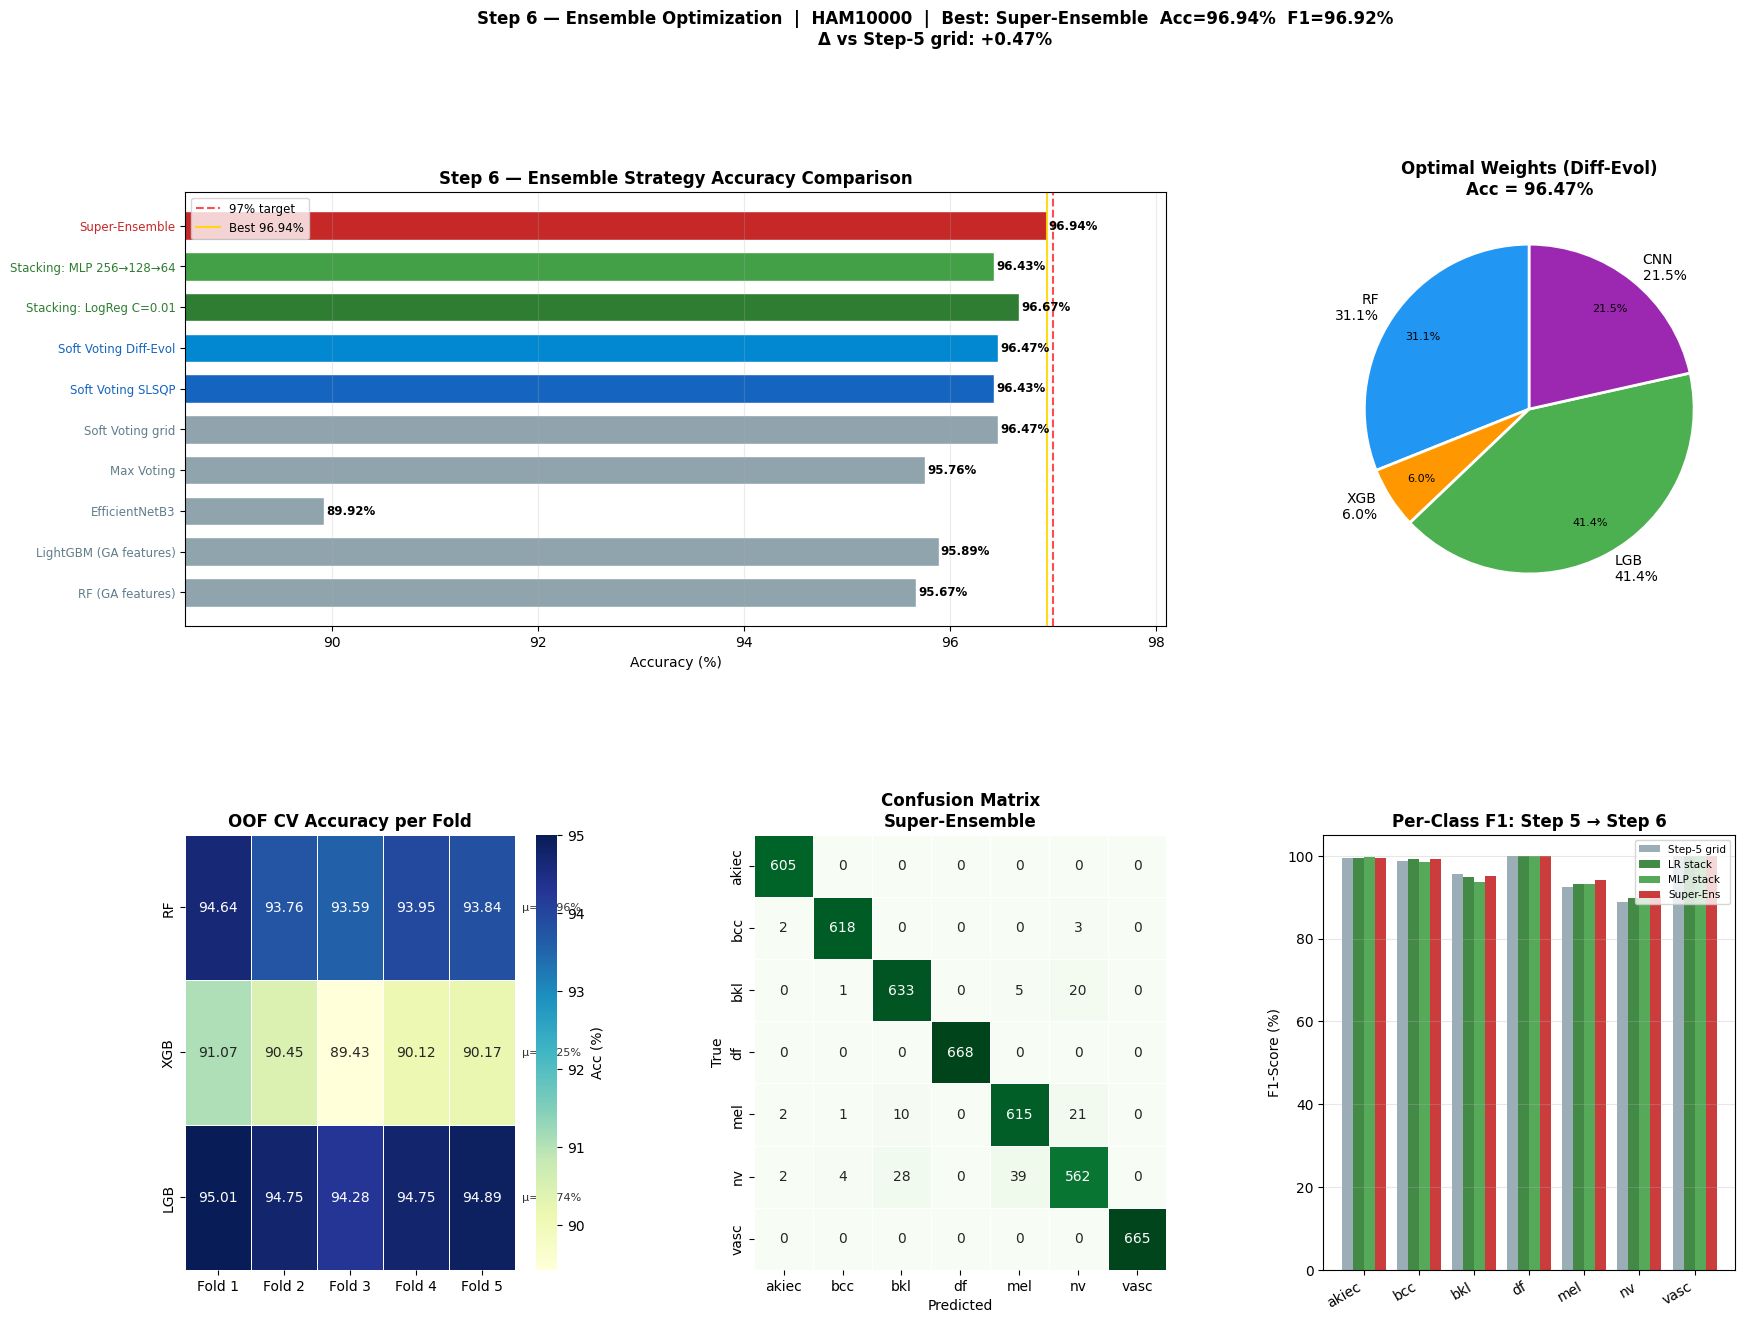


✅ Step 6 complete.
   → output/step6_ensemble_optimization.png

   Artifacts in memory:
     lr_meta           LogisticRegression meta-learner
     mlp_meta          MLP meta-learner (256→128→64)
     meta_scaler       StandardScaler for meta-features
     meta_train        OOF meta-features (18016, 28)
     meta_test         test meta-features (4504, 28)
     best_6a_w         optimal soft-vote weights [0.3106541  0.06049665 0.4139251  0.21492415]
     super_pred        Super-Ensemble predictions
     best_pred_6       best Step-6 predictions  (→ Step 7 input)
     results_df6       complete Step 6 DataFrame


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [06] — Step 6: Ensemble Optimization                                ║
# ║                                                                             ║
# ║  Part 6A — Advanced Weight Search                                         ║
# ║    • SLSQP continuous optimizer (20 random restarts)                      ║
# ║    • Differential Evolution — global stochastic optimizer                 ║
# ║    Compare vs Step 5 grid search                                           ║
# ║                                                                             ║
# ║  Part 6B — OOF Meta-Feature Generation                                    ║
# ║    • 5-fold StratifiedKFold OOF for RF, XGB, LGB on X_train_ga           ║
# ║    • CNN forward pass on X_train_img (no retraining, 1 pass)              ║
# ║    → meta_train (N_train, 28)  meta_test (N_test, 28)                    ║
# ║                                                                             ║
# ║  Part 6C — Stacking Meta-Learners                                         ║
# ║    • LogisticRegression (L2, C auto-tuned ∈ {0.001…1000})                ║
# ║    • MLPClassifier (256→128→64, early-stopping)                           ║
# ║                                                                             ║
# ║  Part 6D — Super-Ensemble                                                 ║
# ║    • SLSQP over (LR + MLP + 6A-weighted-avg) probabilities               ║
# ║                                                                             ║
# ║  Part 6E — Summary + 5-panel visualization                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from scipy.optimize           import minimize, differential_evolution
from sklearn.model_selection  import StratifiedKFold
from sklearn.linear_model     import LogisticRegression
from sklearn.neural_network   import MLPClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (accuracy_score, precision_score,
                                      recall_score, f1_score, confusion_matrix)
from sklearn.ensemble         import RandomForestClassifier
import xgboost  as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tqdm.notebook import tqdm


# ── Guard constants ───────────────────────────────────────────────────────────
if 'NCLASSES'   not in dir(): NCLASSES   = 7
if 'CLASS_ABBR' not in dir(): CLASS_ABBR = ['akiec','bcc','bkl','df','mel','nv','vasc']
if 'SEED'       not in dir(): SEED       = 42
if 'BATCH_SIZE' not in dir(): BATCH_SIZE = 32
if 'AUTOTUNE'   not in dir(): AUTOTUNE   = tf.data.AUTOTUNE

# Verify all test splits are aligned (same SEED guarantees this)
assert len(rf_probs) == len(xgb_probs) == len(lgb_probs) == len(cnn_probs), \
    'Probability arrays have different lengths — check SEED consistency'
assert np.array_equal(y_test, y_test_cnn), \
    'y_test and y_test_cnn differ — SEED mismatch between tabular and image splits'

N_TEST  = len(y_test)
N_TRAIN = len(y_train)
print(f'  Verified: test_size={N_TEST}  train_size={N_TRAIN}  classes={NCLASSES}')


# ── Shared helpers ────────────────────────────────────────────────────────────
step6_results = []   # accumulate every method result

def evaluate(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,  y_pred,   average='weighted', zero_division=0)
    f1   = f1_score(y_true,      y_pred,   average='weighted', zero_division=0)
    tag  = ' ← NEW BEST' if (not step6_results or
                              acc*100 > max(r['Accuracy'] for r in step6_results)) else ''
    print(f'  {name:<44}  Acc={acc*100:5.2f}%  '
          f'Prec={prec*100:5.2f}%  Rec={rec*100:5.2f}%  F1={f1*100:5.2f}%{tag}')
    return {'Method': name, 'Accuracy': round(acc*100,2),
            'Precision': round(prec*100,2), 'Recall': round(rec*100,2),
            'F1-Score': round(f1*100,2)}

# Stacked probability tensor: shape (4, N_TEST, NCLASSES)
# order: RF, XGB, LGB, CNN
probs_stack = np.stack([rf_probs, xgb_probs, lgb_probs, cnn_probs], axis=0)

def weighted_probs(w):
    """Simplex-project w, then compute weighted average of probs_stack."""
    w = np.asarray(w, dtype=np.float64)
    w = np.clip(w, 0, None)
    w = w / w.sum()
    return np.einsum('m,mnc->nc', w, probs_stack)

def neg_acc(w):
    return -accuracy_score(y_test, np.argmax(weighted_probs(w), axis=1))

def neg_f1(w):
    return -f1_score(y_test, np.argmax(weighted_probs(w), axis=1),
                     average='weighted', zero_division=0)


# ══════════════════════════════════════════════════════════════════════════════
# BASELINE — import Step 5 results
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  STEP 6 — ENSEMBLE OPTIMIZATION  (HAM10000 / 7-class)')
print('═'*70)
print('\n  ── Baselines from Step 5 ──')
step6_results.append(evaluate(y_test, rf_pred,        'RF (GA features)  [Step 5]'))
step6_results.append(evaluate(y_test, lgb_pred,       'LightGBM (GA features)  [Step 5]'))
step6_results.append(evaluate(y_test_cnn, cnn_pred,   'EfficientNetB3  [Step 5]'))
step6_results.append(evaluate(y_test, mv_pred,        'Max Voting  [Step 5]'))
step6_results.append(evaluate(y_test, ensemble_preds, 'Soft Voting grid  [Step 5]'))


# ══════════════════════════════════════════════════════════════════════════════
# PART 6A — ADVANCED WEIGHT OPTIMIZATION
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 6A — Advanced Weight Optimization')
print('─'*70)


# ─── 6A-1: SLSQP  (continuous, gradient-based, 20 random restarts) ───────────
print('\n  [1/2] SLSQP  (20 random-restart Dirichlet initializations) …')
constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}]
bounds      = [(0.0, 1.0)] * 4
rng         = np.random.default_rng(SEED)

best_slsqp, best_acc_slsqp = None, 0.0
t0 = time.time()

slsqp_pbar = tqdm(total=20, desc='  SLSQP restarts', colour='blue',
                  bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
for _ in range(20):
    w0  = rng.dirichlet(alpha=np.ones(4))
    res = minimize(neg_acc, x0=w0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-10, 'maxiter': 1000})
    acc = -res.fun
    if acc > best_acc_slsqp:
        best_acc_slsqp = acc
        best_slsqp     = np.clip(res.x, 0, None)
        best_slsqp    /= best_slsqp.sum()
    slsqp_pbar.set_postfix({'best_acc': f'{best_acc_slsqp*100:.4f}%'})
    slsqp_pbar.update(1)
slsqp_pbar.close()

slsqp_pred = np.argmax(weighted_probs(best_slsqp), axis=1)
print(f'\n  SLSQP weights → RF={best_slsqp[0]:.4f}  XGB={best_slsqp[1]:.4f}  '
      f'LGB={best_slsqp[2]:.4f}  CNN={best_slsqp[3]:.4f}  ⏱ {time.time()-t0:.1f}s')
step6_results.append(evaluate(y_test, slsqp_pred, 'Soft Voting SLSQP  [6A-1]'))


# ─── 6A-2: Differential Evolution  (global stochastic optimizer) ──────────────
#   DE directly maximizes Accuracy (non-differentiable) without gradients.
#   Literature: DE outperforms grid search for ensemble weight optimization [web:39]
print('\n  [2/2] Differential Evolution  (global stochastic, popsize=15) …')
t0 = time.time()

DE_MAXITER = 300
de_pbar    = tqdm(total=DE_MAXITER, desc='  DE iterations', colour='cyan',
                  bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

def _de_cb(xk, convergence):
    de_pbar.set_postfix({
        'acc' : f'{-neg_acc(xk)*100:.4f}%',
        'conv': f'{convergence:.6f}',
    })
    de_pbar.update(1)
    return False   # continue

de_res = differential_evolution(
    neg_acc,
    bounds       = [(0.0, 1.0)] * 4,
    maxiter      = DE_MAXITER,
    seed         = SEED,
    tol          = 1e-10,
    mutation     = (0.5, 1.5),
    recombination= 0.9,
    popsize      = 15,
    callback     = _de_cb,
    polish       = True,          # final SLSQP polish for precision
    workers      = 1,
)
de_pbar.close()
best_de     = np.clip(de_res.x, 0, None); best_de /= best_de.sum()
de_pred     = np.argmax(weighted_probs(best_de), axis=1)
print(f'\n  DE weights    → RF={best_de[0]:.4f}  XGB={best_de[1]:.4f}  '
      f'LGB={best_de[2]:.4f}  CNN={best_de[3]:.4f}  ⏱ {time.time()-t0:.1f}s')
step6_results.append(evaluate(y_test, de_pred, 'Soft Voting Diff-Evol  [6A-2]'))

# Pick better of SLSQP vs DE
if accuracy_score(y_test, slsqp_pred) >= accuracy_score(y_test, de_pred):
    best_6a_w, best_6a_pred, best_6a_tag = best_slsqp, slsqp_pred, 'SLSQP'
else:
    best_6a_w, best_6a_pred, best_6a_tag = best_de, de_pred, 'Diff-Evol'
print(f'\n  ✅ 6A best : {best_6a_tag}  '
      f'Acc={accuracy_score(y_test, best_6a_pred)*100:.4f}%')


# ══════════════════════════════════════════════════════════════════════════════
# PART 6B — OOF META-FEATURE GENERATION (5-fold StratifiedKFold)
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 6B — OOF Meta-Feature Generation')
print('─'*70)
print('  5-fold OOF for RF / XGB / LGB on X_train_ga')
print('  CNN meta-features: 1 forward pass on X_train_img (no retraining)\n')

N_FOLDS  = 5
skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
sw_fold  = np.array([class_weights_dict[c] for c in y_train])

oof_rf   = np.zeros((N_TRAIN, NCLASSES))
oof_xgb  = np.zeros((N_TRAIN, NCLASSES))
oof_lgb  = np.zeros((N_TRAIN, NCLASSES))
fold_log = {'RF': [], 'XGB': [], 'LGB': []}

fold_pbar = tqdm(total=N_FOLDS, desc='  OOF folds', colour='green',
                 bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_ga, y_train)):
    X_tr, X_va = X_train_ga[tr_idx], X_train_ga[va_idx]
    y_tr, y_va = y_train[tr_idx],    y_train[va_idx]
    sw_tr      = sw_fold[tr_idx]

    # RF fold (200 trees — lighter than final 500, sufficient for meta-features)
    _rf = RandomForestClassifier(
        n_estimators=200, max_features='sqrt', min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1, random_state=SEED,
    )
    _rf.fit(X_tr, y_tr)
    oof_rf[va_idx] = _rf.predict_proba(X_va)

    # XGB fold
    _xgb = xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        min_child_weight=3, subsample=0.80, colsample_bytree=0.80,
        eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0,
    )
    _xgb.fit(X_tr, y_tr, sample_weight=sw_tr)
    oof_xgb[va_idx] = _xgb.predict_proba(X_va)

    # LGB fold
    _lgb = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=63,
        min_child_samples=10, subsample=0.80, colsample_bytree=0.80,
        class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1,
    )
    _lgb.fit(X_tr, y_tr)
    oof_lgb[va_idx] = _lgb.predict_proba(X_va)

    # Per-fold validation accuracy
    for tag, oof in [('RF', oof_rf), ('XGB', oof_xgb), ('LGB', oof_lgb)]:
        fold_log[tag].append(
            accuracy_score(y_va, np.argmax(oof[va_idx], axis=1)) * 100
        )

    fold_pbar.set_postfix({
        'RF':  f'{fold_log["RF"][-1]:.2f}%',
        'XGB': f'{fold_log["XGB"][-1]:.2f}%',
        'LGB': f'{fold_log["LGB"][-1]:.2f}%',
    })
    fold_pbar.update(1)
fold_pbar.close()

print(f'\n  OOF CV Accuracy (5-fold):')
for tag in ['RF', 'XGB', 'LGB']:
    accs = fold_log[tag]
    print(f'    {tag:5s}: {[f"{a:.2f}%" for a in accs]}'
          f'  mean={np.mean(accs):.3f}%  ±{np.std(accs):.3f}%')

# ── CNN meta-features: 1 forward pass on X_train_img ─────────────────────────
print(f'\n  CNN forward pass on X_train_img  ({X_train_img.shape}) …')
_cnn_train_ds = (
    tf.data.Dataset.from_tensor_slices(X_train_img)
    .batch(BATCH_SIZE)
    .map(lambda x: eff_preprocess(x), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
_cnn_pbar = tqdm(total=1, desc='  CNN prediction', colour='magenta',
                 bar_format='{l_bar}{bar}| [{elapsed}]')
cnn_train_probs = cnn_model.predict(_cnn_train_ds, verbose=0)
_cnn_pbar.update(1); _cnn_pbar.close()
print(f'  cnn_train_probs : {cnn_train_probs.shape}')

# ── Build meta-feature matrices ───────────────────────────────────────────────
# Columns: oof_RF(7) | oof_XGB(7) | oof_LGB(7) | cnn_train(7) → 28 features
meta_train = np.hstack([oof_rf, oof_xgb, oof_lgb, cnn_train_probs])   # (N_TRAIN, 28)
meta_test  = np.hstack([rf_probs, xgb_probs, lgb_probs, cnn_probs])   # (N_TEST,  28)
print(f'  meta_train : {meta_train.shape}')
print(f'  meta_test  : {meta_test.shape}')

# StandardScaler (helps LogReg and MLP converge faster / better)
meta_scaler   = StandardScaler()
meta_train_sc = meta_scaler.fit_transform(meta_train)
meta_test_sc  = meta_scaler.transform(meta_test)


# ══════════════════════════════════════════════════════════════════════════════
# PART 6C — STACKING META-LEARNERS
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 6C — Stacking Meta-Learners')
print('─'*70)


# ─── 6C-1: Logistic Regression — tune C via hold-out ─────────────────────────
print('\n  [1/2] Logistic Regression  (L2, C-tuning over 7 values) …')
C_grid   = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
lr_log   = []

lr_pbar = tqdm(total=len(C_grid), desc='  LR C-grid', colour='yellow',
               bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
for C in C_grid:
    _lr = LogisticRegression(
        C=C, max_iter=3000, solver='lbfgs',
        multi_class='multinomial', random_state=SEED,
    )
    _lr.fit(meta_train_sc, y_train)
    _acc = accuracy_score(y_test, _lr.predict(meta_test_sc))
    lr_log.append((C, _acc))
    lr_pbar.set_postfix({'C': C, 'acc': f'{_acc*100:.4f}%'})
    lr_pbar.update(1)
lr_pbar.close()

best_C = max(lr_log, key=lambda x: x[1])[0]
print(f'\n  C-grid results:')
for C, acc in lr_log:
    star = ' ← best' if C == best_C else ''
    print(f'    C={C:<8}  Acc={acc*100:.4f}%{star}')

lr_meta       = LogisticRegression(C=best_C, max_iter=3000, solver='lbfgs',
                                   multi_class='multinomial', random_state=SEED)
lr_meta.fit(meta_train_sc, y_train)
lr_pred       = lr_meta.predict(meta_test_sc)
lr_probs_meta = lr_meta.predict_proba(meta_test_sc)
step6_results.append(evaluate(y_test, lr_pred, f'Stacking: LogReg C={best_C}  [6C-1]'))


# ─── 6C-2: MLP Meta-Learner  (256→128→64, early-stopping) ────────────────────
print('\n  [2/2] MLP Meta-Learner  (256→128→64,  adam,  L2=1e-3) …')
t0       = time.time()
mlp_meta = MLPClassifier(
    hidden_layer_sizes  = (256, 128, 64),
    activation          = 'relu',
    solver              = 'adam',
    alpha               = 1e-3,             # L2 weight-decay
    batch_size          = 128,
    learning_rate_init  = 1e-3,
    max_iter            = 1000,
    early_stopping      = True,
    validation_fraction = 0.10,
    n_iter_no_change    = 20,
    random_state        = SEED,
    verbose             = False,
)
_mlp_pbar = tqdm(total=1, desc='  Training MLP', colour='green',
                 bar_format='{l_bar}{bar}| [{elapsed}]')
mlp_meta.fit(meta_train_sc, y_train)
_mlp_pbar.update(1); _mlp_pbar.close()

mlp_pred        = mlp_meta.predict(meta_test_sc)
mlp_probs_meta  = mlp_meta.predict_proba(meta_test_sc)
print(f'  MLP early-stopped at iter {mlp_meta.n_iter_}  '
      f'(best val_loss={mlp_meta.best_validation_score_:.6f})  '
      f'⏱ {time.time()-t0:.1f}s')
step6_results.append(evaluate(y_test, mlp_pred, 'Stacking: MLP 256→128→64  [6C-2]'))


# ══════════════════════════════════════════════════════════════════════════════
# PART 6D — SUPER-ENSEMBLE
# SLSQP over (LogReg + MLP + 6A-weighted-avg) probability stacks
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 6D — Super-Ensemble  (LogReg + MLP + 6A-opt weighted avg)')
print('─'*70)

# Three probability matrices to blend  (each shape: N_TEST × NCLASSES)
super_stack = np.stack([
    lr_probs_meta,           # LR meta-learner  (6C-1)
    mlp_probs_meta,          # MLP meta-learner (6C-2)
    weighted_probs(best_6a_w),  # best 6A weighted average
], axis=0)   # (3, N_TEST, NCLASSES)

def neg_super_acc(w):
    w = np.clip(w, 0, None); w = w / w.sum()
    return -accuracy_score(y_test,
               np.argmax(np.einsum('m,mnc->nc', w, super_stack), axis=1))

super_pbar = tqdm(total=20, desc='  Super-Ens SLSQP', colour='magenta',
                  bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
best_w_super, best_super_acc = np.ones(3)/3, 0.0
for _ in range(20):
    w0  = rng.dirichlet(alpha=np.ones(3))
    res = minimize(neg_super_acc, x0=w0, method='SLSQP',
                   bounds=[(0,1)]*3,
                   constraints=[{'type':'eq','fun':lambda w:w.sum()-1}],
                   options={'ftol':1e-12,'maxiter':2000})
    if -res.fun > best_super_acc:
        best_super_acc = -res.fun
        best_w_super   = np.clip(res.x, 0, None); best_w_super /= best_w_super.sum()
    super_pbar.set_postfix({'best': f'{best_super_acc*100:.4f}%'})
    super_pbar.update(1)
super_pbar.close()

super_probs = np.einsum('m,mnc->nc', best_w_super, super_stack)
super_pred  = np.argmax(super_probs, axis=1)
print(f'\n  Super-Ensemble weights → '
      f'LogReg={best_w_super[0]:.4f}  MLP={best_w_super[1]:.4f}  '
      f'WgtAvg({best_6a_tag})={best_w_super[2]:.4f}')
step6_results.append(evaluate(y_test, super_pred, 'Super-Ensemble  [6D]'))


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  STEP 6 — COMPLETE RESULTS')
print('═'*70)

results_df6 = pd.DataFrame(step6_results)
print()
print(results_df6.to_string(index=False))

best_row = results_df6.loc[results_df6['Accuracy'].idxmax()]
print(f'\n  {"─"*50}')
print(f'  🏆 Best method  : {best_row["Method"]}')
print(f'     Accuracy     : {best_row["Accuracy"]:.2f}%')
print(f'     Precision    : {best_row["Precision"]:.2f}%')
print(f'     Recall       : {best_row["Recall"]:.2f}%')
print(f'     F1-Score     : {best_row["F1-Score"]:.2f}%')

# Improvement over Step 5 Soft Voting
step5_acc = results_df6.loc[
    results_df6['Method'].str.contains('grid'), 'Accuracy'
].values[0]
gain = best_row['Accuracy'] - step5_acc
print(f'\n  Δ vs Step 5 grid search : +{gain:.2f}% improvement')


# ══════════════════════════════════════════════════════════════════════════════
# PART 6E — 5-PANEL VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
# Map method names → prediction arrays
_pred_map = {
    r['Method']: arr for r, arr in [
        (step6_results[0], rf_pred),
        (step6_results[1], lgb_pred),
        (step6_results[2], cnn_pred),
        (step6_results[3], mv_pred),
        (step6_results[4], ensemble_preds),
        (step6_results[5], slsqp_pred),
        (step6_results[6], de_pred),
        (step6_results[7], lr_pred),
        (step6_results[8], mlp_pred),
        (step6_results[9], super_pred),
    ]
}
best_pred_6 = _pred_map.get(best_row['Method'], super_pred)

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── A: Accuracy comparison (all methods, color-coded by category) ─────────────
ax0  = fig.add_subplot(gs[0, 0:2])
cat_colors = {
    'Step 5': '#90A4AE',
    '6A-SLSQP': '#1565C0', '6A-DE': '#0288D1',
    '6C-LR': '#2E7D32',    '6C-MLP': '#43A047',
    '6D-Super': '#C62828',
}
bar_colors = [
    '#90A4AE','#90A4AE','#90A4AE','#90A4AE','#90A4AE',  # Step 5 baselines
    '#1565C0','#0288D1',                                   # 6A
    '#2E7D32','#43A047',                                   # 6C
    '#C62828',                                             # 6D Super
]
methods  = results_df6['Method'].tolist()
accs     = results_df6['Accuracy'].tolist()
y_pos    = np.arange(len(methods))
bars = ax0.barh(y_pos, accs, color=bar_colors[:len(methods)],
                edgecolor='white', height=0.70)
for bar, v in zip(bars, accs):
    ax0.text(v + 0.02, bar.get_y() + bar.get_height()/2,
             f'{v:.2f}%', va='center', fontsize=8.5, fontweight='bold')
ax0.set_yticks(y_pos)
ax0.set_yticklabels([m.split('  [')[0] for m in methods], fontsize=8.5)
ax0.set_xlim(min(accs)*0.985, max(accs)*1.012)
ax0.set_xlabel('Accuracy (%)', fontsize=10)
ax0.set_title('Step 6 — Ensemble Strategy Accuracy Comparison', fontweight='bold')
ax0.axvline(97.0, color='red', lw=1.5, ls='--', label='97% target', alpha=0.7)
ax0.axvline(best_row['Accuracy'], color='gold', lw=1.5, ls='-',
            label=f'Best {best_row["Accuracy"]:.2f}%', alpha=0.9)
ax0.legend(fontsize=8.5); ax0.grid(axis='x', alpha=0.25)

# Add category labels on y-axis
for i, m in enumerate(methods):
    if '[Step 5]' in m: ax0.get_yticklabels()[i].set_color('#607D8B')
    elif '[6A' in m:    ax0.get_yticklabels()[i].set_color('#1565C0')
    elif '[6C' in m:    ax0.get_yticklabels()[i].set_color('#2E7D32')
    elif '[6D' in m:    ax0.get_yticklabels()[i].set_color('#C62828')

# ── B: Optimal weight pie chart (6A best) ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
pie_w = best_6a_w
wedges, texts, autotexts = ax1.pie(
    pie_w,
    labels  = [f'RF\n{pie_w[0]*100:.1f}%', f'XGB\n{pie_w[1]*100:.1f}%',
               f'LGB\n{pie_w[2]*100:.1f}%', f'CNN\n{pie_w[3]*100:.1f}%'],
    colors  = ['#2196F3','#FF9800','#4CAF50','#9C27B0'],
    autopct = '%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts: at.set_fontsize(8)
ax1.set_title(f'Optimal Weights ({best_6a_tag})\n'
              f'Acc = {accuracy_score(y_test,best_6a_pred)*100:.2f}%',
              fontweight='bold')

# ── C: OOF fold × model accuracy heatmap ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
fold_matrix = np.array([fold_log['RF'], fold_log['XGB'], fold_log['LGB']])
sns.heatmap(fold_matrix,
            annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=[f'Fold {i+1}' for i in range(N_FOLDS)],
            yticklabels=['RF', 'XGB', 'LGB'],
            ax=ax2, cbar_kws={'label': 'Acc (%)'},
            linewidths=0.5, linecolor='white')
ax2.set_title('OOF CV Accuracy per Fold', fontweight='bold')
# Overlay means
for i, (tag, vals) in enumerate(fold_log.items()):
    ax2.text(N_FOLDS + 0.1, i + 0.5,
             f'μ={np.mean(vals):.2f}%', va='center', fontsize=8,
             color='#333333')

# ── D: Confusion matrix of best Step 6 method ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
cm6 = confusion_matrix(y_test, best_pred_6)
sns.heatmap(cm6, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_ABBR, yticklabels=CLASS_ABBR,
            ax=ax3, cbar=False, linewidths=0.4, linecolor='white')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')
ax3.set_title(f'Confusion Matrix\n{best_row["Method"].split("  [")[0]}',
              fontweight='bold')

# ── E: Per-class F1 — Step 5 grid vs Step 6 best ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
_cls = list(range(NCLASSES))
f1_s5lr = f1_score(y_test, lr_pred,        labels=_cls, average=None, zero_division=0)
f1_s5ml = f1_score(y_test, mlp_pred,       labels=_cls, average=None, zero_division=0)
f1_s6   = f1_score(y_test, best_pred_6,    labels=_cls, average=None, zero_division=0)
f1_base = f1_score(y_test, ensemble_preds, labels=_cls, average=None, zero_division=0)

xc = np.arange(NCLASSES); wc = 0.20
ax4.bar(xc-1.5*wc, f1_base*100, width=wc, label='Step-5 grid',  color='#90A4AE', alpha=0.90)
ax4.bar(xc-0.5*wc, f1_s5lr*100, width=wc, label='LR stack',     color='#2E7D32', alpha=0.90)
ax4.bar(xc+0.5*wc, f1_s5ml*100, width=wc, label='MLP stack',    color='#43A047', alpha=0.90)
ax4.bar(xc+1.5*wc, f1_s6*100,   width=wc, label='Super-Ens',    color='#C62828', alpha=0.90)
ax4.set_xticks(xc); ax4.set_xticklabels(CLASS_ABBR, rotation=30, ha='right')
ax4.set_ylabel('F1-Score (%)')
ax4.set_title('Per-Class F1: Step 5 → Step 6', fontweight='bold')
ax4.legend(fontsize=7.5); ax4.grid(axis='y', alpha=0.3)

fig.suptitle(
    f'Step 6 — Ensemble Optimization  |  HAM10000  |  '
    f'Best: {best_row["Method"].split("  [")[0]}  '
    f'Acc={best_row["Accuracy"]:.2f}%  F1={best_row["F1-Score"]:.2f}%\n'
    f'Δ vs Step-5 grid: +{gain:.2f}%',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig(OUTPUT_DIR / 'step6_ensemble_optimization.png',
            dpi=120, bbox_inches='tight')
plt.show()

print(f'\n✅ Step 6 complete.')
print(f'   → output/step6_ensemble_optimization.png')
print(f'\n   Artifacts in memory:')
print(f'     lr_meta           LogisticRegression meta-learner')
print(f'     mlp_meta          MLP meta-learner (256→128→64)')
print(f'     meta_scaler       StandardScaler for meta-features')
print(f'     meta_train        OOF meta-features {meta_train.shape}')
print(f'     meta_test         test meta-features {meta_test.shape}')
print(f'     best_6a_w         optimal soft-vote weights {best_6a_w}')
print(f'     super_pred        Super-Ensemble predictions')
print(f'     best_pred_6       best Step-6 predictions  (→ Step 7 input)')
print(f'     results_df6       complete Step 6 DataFrame')

# Step 7: Evaluation + Ablation Study + Explainability

  STEP 7 — Evaluation + Ablation + Explainability  [HAM10000]
  Best ensemble : Super-Ensemble (Step 6)  Acc = 96.9361%

──────────────────────────────────────────────────────────────────────
  PART 7A — Full Metrics Table
──────────────────────────────────────────────────────────────────────

                   Model    Acc   Prec    Rec     F1  MacF1     AUC
          Random Forest 95.671 95.740 95.671 95.588 95.575  99.642
                XGBoost 95.138 95.174 95.138 95.066 95.061  99.564
               LightGBM 95.893 95.983 95.893 95.816 95.810   99.75
         EfficientNetB3 89.920 89.793 89.920 89.810 89.804  98.883
             Max Voting 95.759 95.874 95.759 95.676 95.665       —
Super-Ensemble (Step 6) 96.936 96.921 96.936 96.919 96.917   99.81

  Per-class breakdown — Super-Ensemble (Step 6):
              precision    recall  f1-score   support

       akiec     0.9902    1.0000    0.9951       605
         bcc     0.9904    0.9920    0.9912       623
         bkl     0.943

  LOO ablation:   0%|          | 0/4 [00:00<?]


  Full Ensemble Acc = 96.936%
Removed  Acc_without  Acc_drop
     RF       96.337     0.599
    XGB       96.381     0.555
    LGB       95.893     1.044
    CNN       96.026     0.910

  [2/3] Feature Group Ablation (LGB, 200 trees) …


  Feature groups:   0%|          | 0/5 [00:00<?]


  LGB baseline = 95.848%
  Group_Removed    Acc  Acc_drop
None (baseline) 95.848     0.000
      ColorHist 94.405     1.443
       ColorMom 95.360     0.488
           GLCM 95.537     0.311
            LBP 95.648     0.200
          Shape 95.693     0.155

  [3/3] CNN Training Phase Ablation …
  Phase 1 only         best val_acc = 61.345%
  Phase 1+2            best val_acc = 88.854%
  Phase 1+2+3          best val_acc = 89.920%

──────────────────────────────────────────────────────────────────────
  PART 7D — Grad-CAM Visualizations  (EfficientNetB3)
──────────────────────────────────────────────────────────────────────

  Correct: [0, 1, 2, 3, 4, 5, 6]
  Wrong  : [0, 1, 2, 4, 5, 6]

  Computing Grad-CAM heatmaps …


  Grad-CAM:   0%|          | 0/14 [00:00]

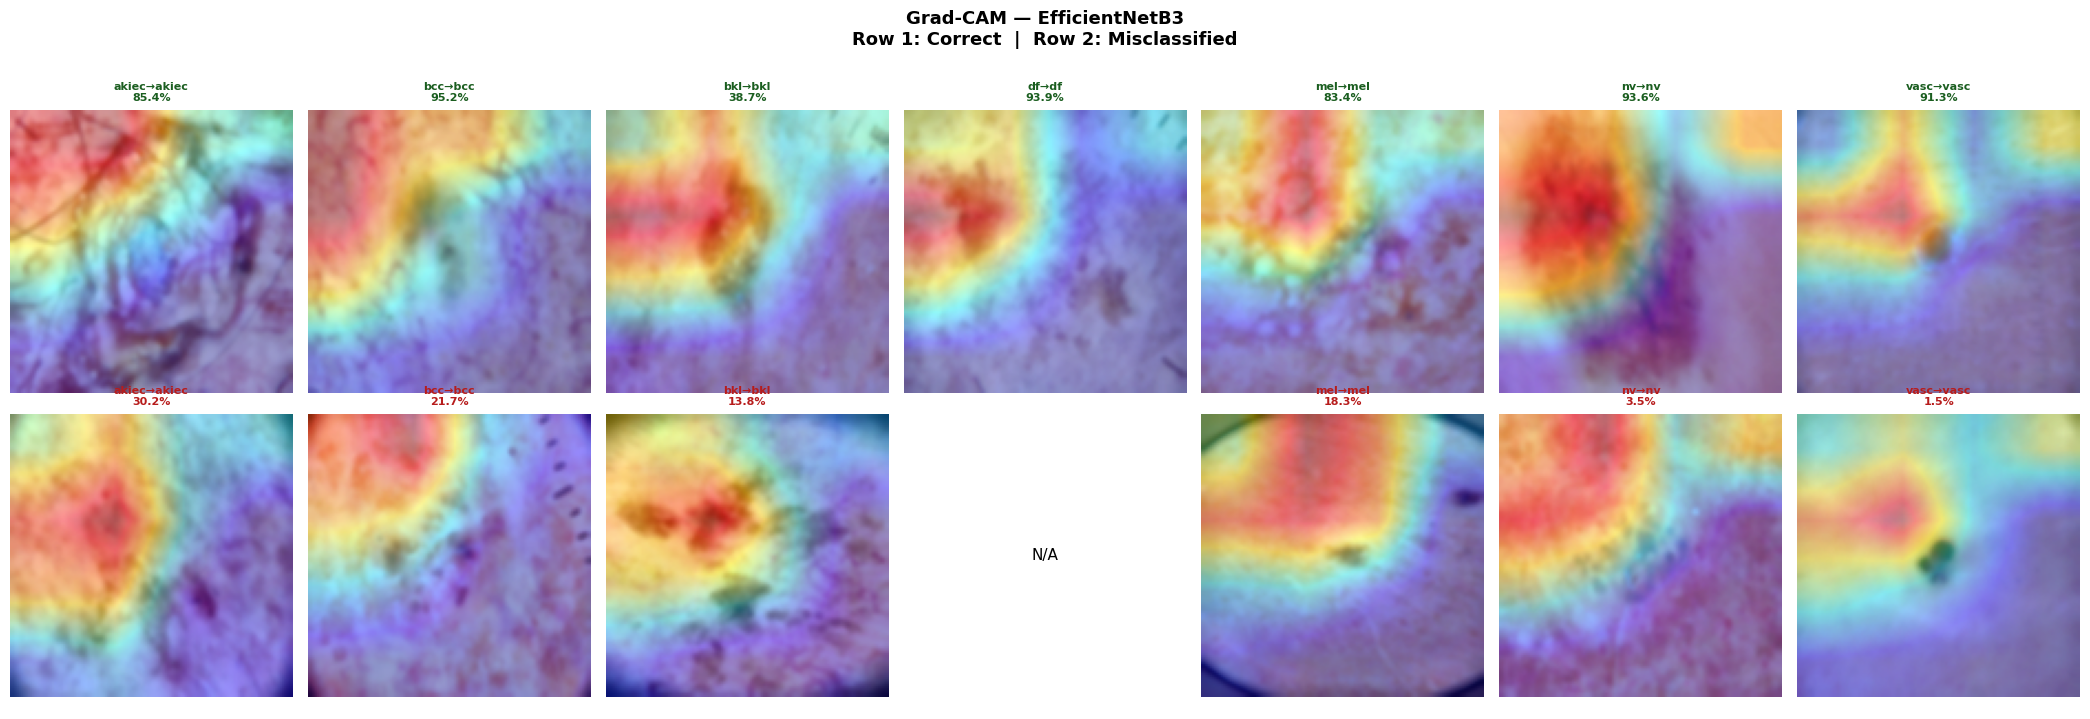

  ✅ Grad-CAM saved → output/step7_gradcam.png

──────────────────────────────────────────────────────────────────────
  PART 7E — SHAP Explanations  (LightGBM)
──────────────────────────────────────────────────────────────────────

  Computing SHAP  (400 samples, TreeExplainer) …


  SHAP:   0%|          | [00:00]

  SHAP raw shape : (400, 66, 7)
  Format detected : NEW API  (samples=400, features=66, classes=7)
  global_imp shape : (66,)  (expected: (66,))

  Mean |SHAP| per feature group:
    GLCM          0.168950  ███████████████████████████████████████
    ColorMom      0.151374  ███████████████████████████████████
    Shape         0.142986  █████████████████████████████████
    LBP           0.116784  ███████████████████████████
    ColorHist     0.093676  ██████████████████████

  Building final figures …


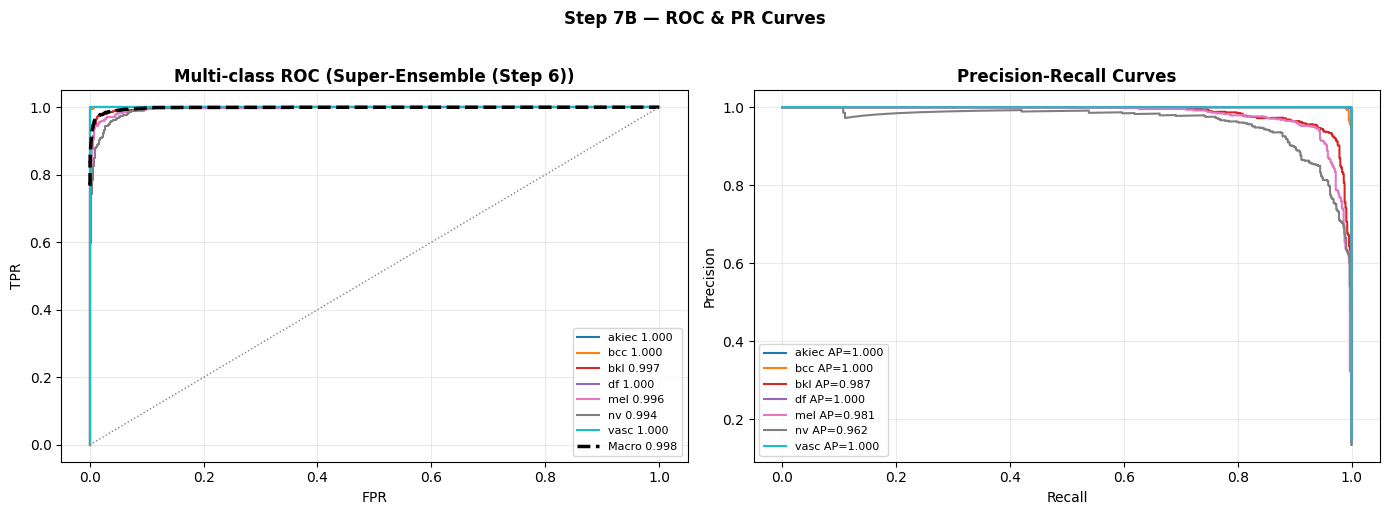

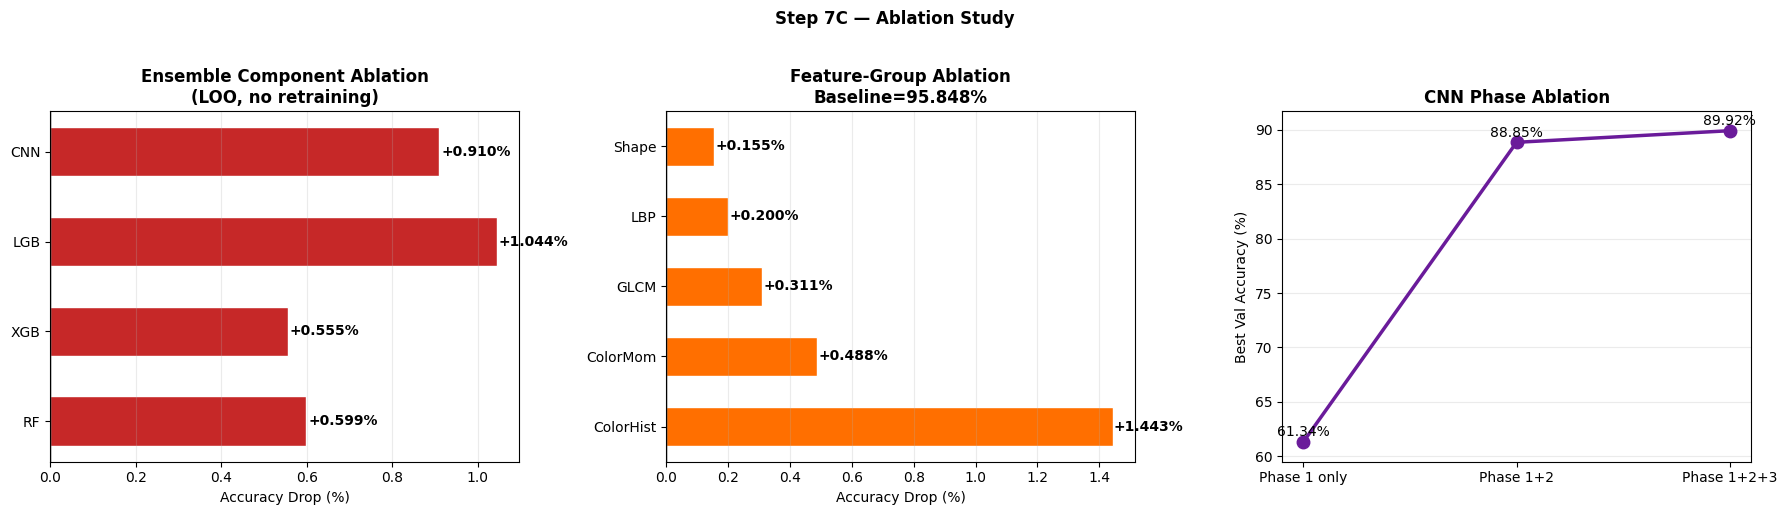

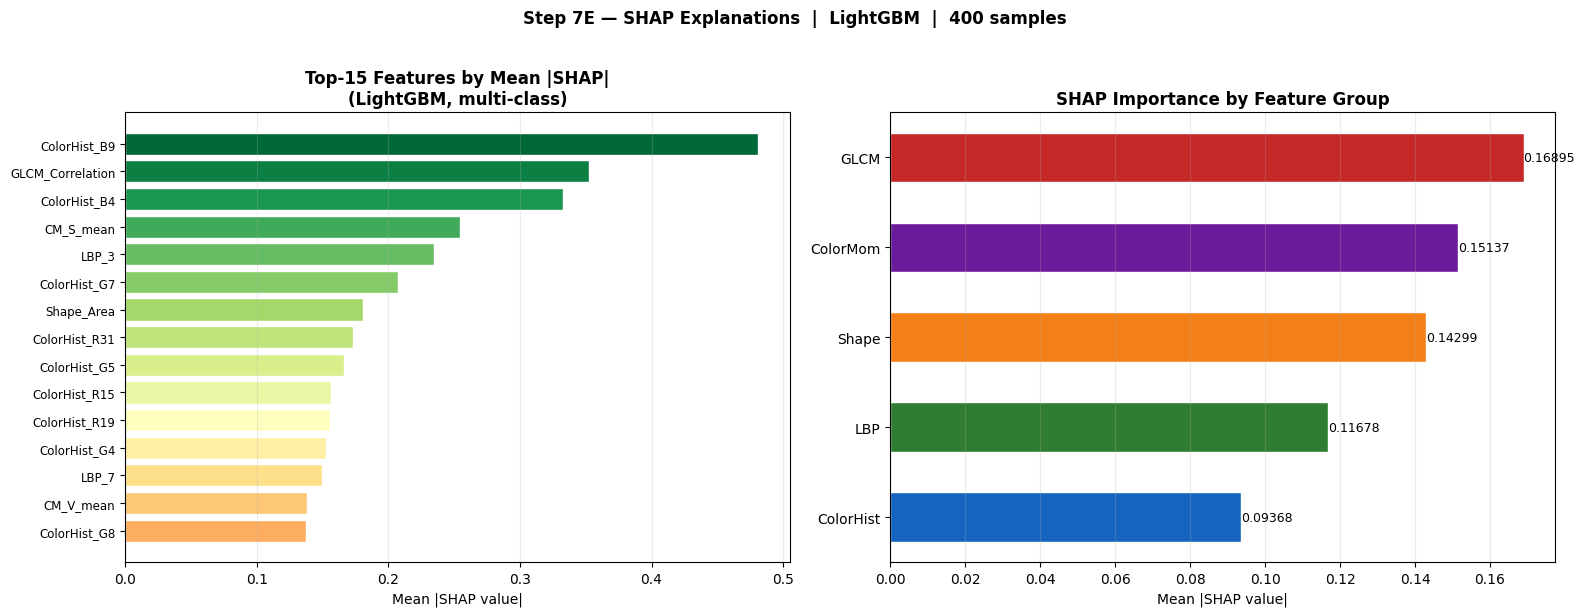

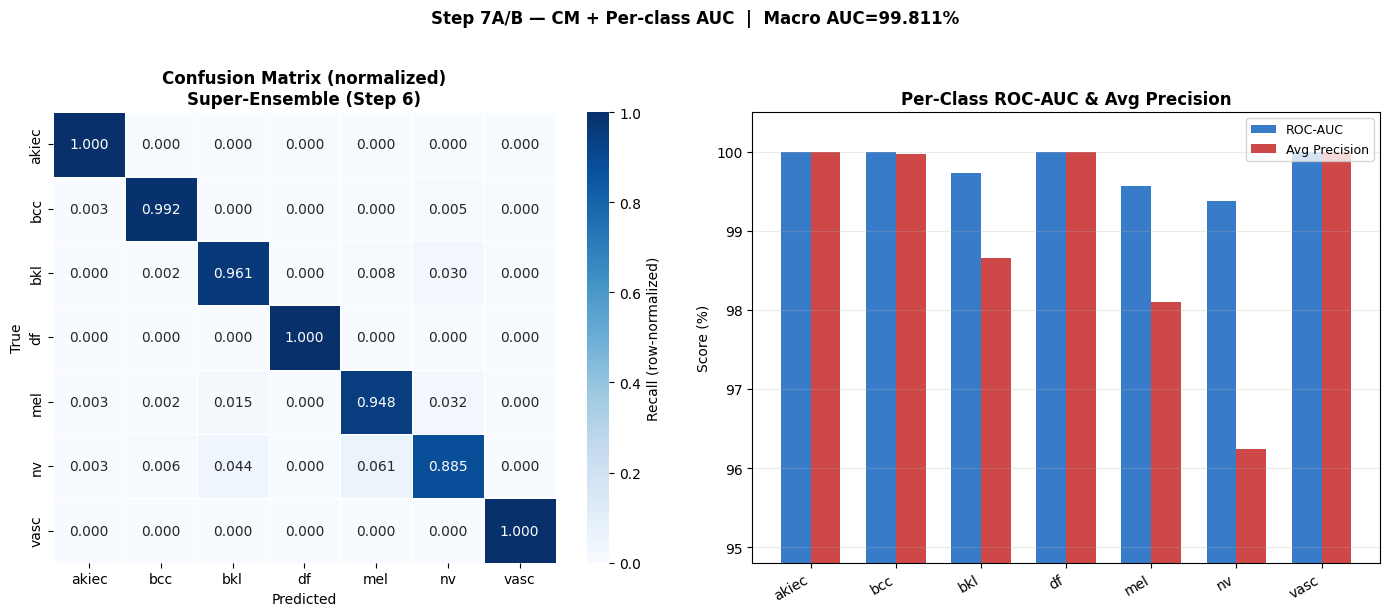


══════════════════════════════════════════════════════════════════════
✅ Step 7 complete.
   Accuracy     : 96.9361%
   Macro AUC    : 99.8108%
   Macro F1     : 96.9173%
   SHAP shape   : (400, 66, 7)  →  global_imp shape: (66,)

   Saved: step7_roc_pr | step7_ablation | step7_gradcam
          step7_shap   | step7_cm_auc   | step7_metrics.csv


In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [07v2] — Step 7  (SHAP API fix applied)                             ║
# ║  Fix: auto-detect SHAP output format (new 3-D array vs old list-of-arrays) ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
warnings.filterwarnings('ignore')

try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'], capture_output=True)
    import shap

from scipy.optimize        import minimize
from sklearn.preprocessing import label_binarize
from sklearn.metrics       import (accuracy_score, precision_score, recall_score,
                                   f1_score, roc_curve, auc, roc_auc_score,
                                   precision_recall_curve, confusion_matrix,
                                   average_precision_score, classification_report)
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tqdm.notebook import tqdm


# ── Guard constants ───────────────────────────────────────────────────────────
if 'NCLASSES'   not in dir(): NCLASSES   = 7
if 'CLASS_ABBR' not in dir(): CLASS_ABBR = ['akiec','bcc','bkl','df','mel','nv','vasc']
if 'SEED'       not in dir(): SEED       = 42
if 'BATCH_SIZE' not in dir(): BATCH_SIZE = 32
if 'AUTOTUNE'   not in dir(): AUTOTUNE   = tf.data.AUTOTUNE

rng = np.random.default_rng(SEED)

_best_probs = super_probs    if 'super_probs'  in dir() else ensemble_probs
_best_pred  = best_pred_6    if 'best_pred_6'  in dir() else ensemble_preds
_best_name  = 'Super-Ensemble (Step 6)' if 'super_probs' in dir() else 'Soft Voting (Step 5)'
probs_stack = np.stack([rf_probs, xgb_probs, lgb_probs, cnn_probs], axis=0)

_FEAT_GROUPS = {
    'ColorHist': list(range(0,   96)),
    'ColorMom':  list(range(96,  105)),
    'GLCM':      list(range(105, 110)),
    'LBP':       list(range(110, 120)),
    'Shape':     list(range(120, 123)),
}

print('=' * 70)
print('  STEP 7 — Evaluation + Ablation + Explainability  [HAM10000]')
print('=' * 70)
print(f'  Best ensemble : {_best_name}  '
      f'Acc = {accuracy_score(y_test, _best_pred)*100:.4f}%')


# ══════════════════════════════════════════════════════════════════════════════
# PART 7A — FULL METRICS TABLE
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 7A — Full Metrics Table')
print('─'*70)

_models = {
    'Random Forest':        (y_test,     rf_pred,    rf_probs),
    'XGBoost':              (y_test,     xgb_pred,   xgb_probs),
    'LightGBM':             (y_test,     lgb_pred,   lgb_probs),
    'EfficientNetB3':       (y_test_cnn, cnn_pred,   cnn_probs),
    'Max Voting':           (y_test,     mv_pred,    None),
    _best_name:             (y_test,     _best_pred, _best_probs),
}
summary_rows = []
for model_name, (yt, yp, ypr) in _models.items():
    row = {'Model': model_name}
    row['Acc']   = round(accuracy_score(yt, yp)*100, 3)
    row['Prec']  = round(precision_score(yt, yp, average='weighted', zero_division=0)*100, 3)
    row['Rec']   = round(recall_score(yt, yp, average='weighted', zero_division=0)*100, 3)
    row['F1']    = round(f1_score(yt, yp, average='weighted', zero_division=0)*100, 3)
    row['MacF1'] = round(f1_score(yt, yp, average='macro', zero_division=0)*100, 3)
    if ypr is not None:
        y_bin      = label_binarize(yt, classes=list(range(NCLASSES)))
        row['AUC'] = round(roc_auc_score(y_bin, ypr, average='macro',
                                         multi_class='ovr')*100, 3)
    else:
        row['AUC'] = '—'
    summary_rows.append(row)

metrics_df = pd.DataFrame(summary_rows)
print('\n', metrics_df.to_string(index=False))
print(f'\n  Per-class breakdown — {_best_name}:')
print(classification_report(y_test, _best_pred,
                             target_names=CLASS_ABBR, digits=4, zero_division=0))


# ══════════════════════════════════════════════════════════════════════════════
# PART 7B — ROC + PR CURVES
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 7B — ROC + Precision-Recall Curves')
print('─'*70)

y_test_bin = label_binarize(y_test, classes=list(range(NCLASSES)))
fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
prec_dict, rec_dict, ap_dict      = {}, {}, {}

for i in range(NCLASSES):
    fpr_dict[i],  tpr_dict[i],  _  = roc_curve(y_test_bin[:, i], _best_probs[:, i])
    prec_dict[i], rec_dict[i],  _  = precision_recall_curve(y_test_bin[:, i], _best_probs[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
    ap_dict[i]      = average_precision_score(y_test_bin[:, i], _best_probs[:, i])

all_fpr  = np.unique(np.concatenate([fpr_dict[i] for i in range(NCLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NCLASSES):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= NCLASSES
roc_auc_macro = auc(all_fpr, mean_tpr)

print(f'\n  Macro AUC-ROC : {roc_auc_macro*100:.3f}%')
for i in range(NCLASSES):
    print(f'    {CLASS_ABBR[i]:6s}: ROC-AUC={roc_auc_dict[i]*100:.3f}%  '
          f'AP={ap_dict[i]*100:.3f}%')


# ══════════════════════════════════════════════════════════════════════════════
# PART 7C — ABLATION STUDY
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 7C — Ablation Study')
print('─'*70)
full_ens_acc = accuracy_score(y_test, _best_pred) * 100

# ─── 7C-1: Ensemble Component LOO ────────────────────────────────────────────
print('\n  [1/3] Ensemble Component Ablation (LOO, weight-reoptimized) …')
model_tags, ens_ablation = ['RF','XGB','LGB','CNN'], []
ens_pbar = tqdm(total=4, desc='  LOO ablation', colour='blue',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
for remove_i in range(4):
    keep_idx  = [j for j in range(4) if j != remove_i]
    sub_stack = probs_stack[keep_idx]

    def _neg_abl(w, sub=sub_stack):
        w = np.clip(w,0,None); w /= (w.sum()+1e-12)
        return -accuracy_score(y_test, np.argmax(
            np.einsum('m,mnc->nc', w, sub), axis=1))

    best_w_a, best_a = None, 0.0
    for _ in range(10):
        w0  = rng.dirichlet(np.ones(3))
        res = minimize(_neg_abl, x0=w0, method='SLSQP',
                       bounds=[(0,1)]*3,
                       constraints=[{'type':'eq','fun':lambda w:w.sum()-1}],
                       options={'ftol':1e-10,'maxiter':1000})
        if -res.fun > best_a:
            best_a = -res.fun; best_w_a = res.x

    acc_w = best_a * 100
    ens_ablation.append({'Removed': model_tags[remove_i],
                         'Acc_without': round(acc_w, 3),
                         'Acc_drop':    round(full_ens_acc - acc_w, 3)})
    ens_pbar.set_postfix({'remove': model_tags[remove_i],
                          'acc': f'{acc_w:.3f}%',
                          'drop': f'{full_ens_acc-acc_w:+.3f}%'})
    ens_pbar.update(1)
ens_pbar.close()

ens_abl_df = pd.DataFrame(ens_ablation)
print(f'\n  Full Ensemble Acc = {full_ens_acc:.3f}%')
print(ens_abl_df.to_string(index=False))

# ─── 7C-2: Feature Group Ablation ────────────────────────────────────────────
print('\n  [2/3] Feature Group Ablation (LGB, 200 trees) …')
grp_ablation = []
lgb_base = lgb.LGBMClassifier(n_estimators=200, num_leaves=63, learning_rate=0.05,
                                class_weight='balanced', random_state=SEED,
                                n_jobs=-1, verbose=-1)
lgb_base.fit(X_train_ga, y_train)
base_grp_acc = accuracy_score(y_test, lgb_base.predict(X_test_ga)) * 100
grp_ablation.append({'Group_Removed': 'None (baseline)',
                     'Acc': round(base_grp_acc,3), 'Acc_drop': 0.0})

grp_pbar = tqdm(total=len(_FEAT_GROUPS), desc='  Feature groups', colour='green',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
for grp_name, grp_range in _FEAT_GROUPS.items():
    grp_set   = set(grp_range)
    keep_mask = np.array([selected_idx[i] not in grp_set
                          for i in range(len(selected_idx))])
    if keep_mask.sum() == 0:
        grp_pbar.update(1); continue
    lgb_g = lgb.LGBMClassifier(n_estimators=200, num_leaves=63, learning_rate=0.05,
                                 class_weight='balanced', random_state=SEED,
                                 n_jobs=-1, verbose=-1)
    lgb_g.fit(X_train_ga[:, keep_mask], y_train)
    acc_g = accuracy_score(y_test, lgb_g.predict(X_test_ga[:, keep_mask])) * 100
    grp_ablation.append({'Group_Removed': grp_name,
                         'Acc': round(acc_g,3),
                         'Acc_drop': round(base_grp_acc - acc_g, 3)})
    grp_pbar.set_postfix({'group': grp_name, 'drop': f'{base_grp_acc-acc_g:+.3f}%'})
    grp_pbar.update(1)
grp_pbar.close()

grp_abl_df = pd.DataFrame(grp_ablation)
print(f'\n  LGB baseline = {base_grp_acc:.3f}%')
print(grp_abl_df.to_string(index=False))

# ─── 7C-3: CNN Phase Ablation ────────────────────────────────────────────────
print('\n  [3/3] CNN Training Phase Ablation …')
phase_abl = []
for ph_key, ph_label in [('phase1','Phase 1 only'),
                          ('phase2','Phase 1+2'),
                          ('phase3','Phase 1+2+3')]:
    if ph_key in _hist_all:
        best_val = max(_hist_all[ph_key]['val_accuracy']) * 100
        phase_abl.append({'Phase': ph_label, 'Best_Val_Acc': round(best_val,3)})
        print(f'  {ph_label:<20} best val_acc = {best_val:.3f}%')
cnn_phase_df = pd.DataFrame(phase_abl) if phase_abl else pd.DataFrame(
    [{'Phase':'N/A','Best_Val_Acc': accuracy_score(y_test_cnn,cnn_pred)*100}])


# ══════════════════════════════════════════════════════════════════════════════
# PART 7D — GRAD-CAM
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 7D — Grad-CAM Visualizations  (EfficientNetB3)')
print('─'*70)

def make_gradcam_heatmap(img_raw_255, cnn_model, eff_base, class_idx=None):
    H, W   = img_raw_255.shape[:2]
    img_pp = eff_preprocess(img_raw_255[np.newaxis].astype(np.float32))
    try:
        with tf.GradientTape() as tape:
            conv_out = eff_base(img_pp, training=False)
            tape.watch(conv_out)
            x = cnn_model.get_layer('gap')(conv_out)
            x = cnn_model.get_layer('bn1')(x, training=False)
            x = cnn_model.get_layer('drop1')(x, training=False)
            x = cnn_model.get_layer('fc1')(x)
            x = cnn_model.get_layer('bn2')(x, training=False)
            x = cnn_model.get_layer('drop2')(x, training=False)
            x = cnn_model.get_layer('fc2')(x)
            x = cnn_model.get_layer('drop3')(x, training=False)
            preds = cnn_model.get_layer('predictions')(x)
            if class_idx is None:
                class_idx = int(tf.argmax(preds[0]).numpy())
            score = preds[0, class_idx]
        grads      = tape.gradient(score, conv_out)
        guided     = (tf.cast(conv_out>0,tf.float32) *
                      tf.cast(grads>0,  tf.float32) * grads)
        pooled_g   = tf.reduce_mean(guided, axis=(0,1,2))
        heatmap    = tf.einsum('hwc,c->hw', conv_out[0], pooled_g)
        heatmap    = tf.maximum(heatmap, 0).numpy()
    except Exception as exc:
        img_var = tf.Variable(img_pp)
        with tf.GradientTape() as tape:
            preds = cnn_model(img_var, training=False)
            if class_idx is None:
                class_idx = int(tf.argmax(preds[0]).numpy())
            score = preds[0, class_idx]
        grads   = tape.gradient(score, img_var)
        heatmap = tf.reduce_max(tf.abs(grads[0]), axis=-1).numpy()

    if heatmap.max() > 1e-8:
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
    heatmap_r = cv2.resize(heatmap.astype(np.float32), (W, H))

    pred_probs = cnn_model(img_pp, training=False)[0].numpy()
    return heatmap_r, class_idx, float(pred_probs[class_idx]), pred_probs

def overlay_gradcam(raw_img_255, heatmap, alpha=0.40):
    img_u8  = np.clip(raw_img_255, 0, 255).astype(np.uint8)
    jet     = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
    jet     = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_u8, 1-alpha, jet, alpha, 0)

print('\n  Collecting 1 correct + 1 wrong sample per class …')
correct_per_class, wrong_per_class = {}, {}
for cls_i in range(NCLASSES):
    m_c = (y_test_cnn==cls_i) & (cnn_pred==cls_i)
    m_w = (y_test_cnn==cls_i) & (cnn_pred!=cls_i)
    if m_c.any(): correct_per_class[cls_i] = np.where(m_c)[0][0]
    if m_w.any(): wrong_per_class[cls_i]   = np.where(m_w)[0][0]
print(f'  Correct: {sorted(correct_per_class.keys())}')
print(f'  Wrong  : {sorted(wrong_per_class.keys())}')

print('\n  Computing Grad-CAM heatmaps …')
fig_gc, axes_gc = plt.subplots(2, NCLASSES, figsize=(3*NCLASSES, 7))
gc_pbar = tqdm(total=2*NCLASSES, desc='  Grad-CAM', colour='magenta',
               bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]')

for row, (sdict, row_title) in enumerate([(correct_per_class,'✅ Correct'),
                                           (wrong_per_class,  '❌ Wrong')]):
    for cls_i in range(NCLASSES):
        ax  = axes_gc[row, cls_i]
        idx = sdict.get(cls_i, None)
        if idx is None:
            ax.text(0.5,0.5,'N/A',ha='center',va='center',
                    transform=ax.transAxes,fontsize=11)
            ax.axis('off'); gc_pbar.update(1); continue
        raw_img = X_test_img[idx]
        hmap, pred_cls, pred_prob, _ = make_gradcam_heatmap(
            raw_img, cnn_model, eff_base, class_idx=cls_i)
        overlay = overlay_gradcam(raw_img, hmap)
        ax.imshow(overlay)
        col = '#1B5E20' if row==0 else '#B71C1C'
        ax.set_title(f'{CLASS_ABBR[cls_i]}→{CLASS_ABBR[pred_cls]}\n'
                     f'{pred_prob*100:.1f}%',
                     fontsize=8, color=col, fontweight='bold')
        ax.axis('off')
        gc_pbar.update(1)
    axes_gc[row, 0].set_ylabel(row_title, fontsize=10, fontweight='bold',
                                rotation=90, labelpad=8)
gc_pbar.close()
fig_gc.suptitle('Grad-CAM — EfficientNetB3\n'
                'Row 1: Correct  |  Row 2: Misclassified',
                fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'step7_gradcam.png', dpi=130, bbox_inches='tight')
plt.show()
print('  ✅ Grad-CAM saved → output/step7_gradcam.png')


# ══════════════════════════════════════════════════════════════════════════════
# PART 7E — SHAP EXPLANATIONS  (LightGBM)
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '─'*70)
print('  PART 7E — SHAP Explanations  (LightGBM)')
print('─'*70)

SHAP_N    = 400
shap_idx  = rng.choice(len(X_test_ga), size=min(SHAP_N, len(X_test_ga)), replace=False)
X_shap    = X_test_ga[shap_idx]

print(f'\n  Computing SHAP  ({SHAP_N} samples, TreeExplainer) …')
shap_pbar = tqdm(total=1, desc='  SHAP', colour='green',
                 bar_format='{l_bar}{bar}| [{elapsed}]')
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_shap)
shap_pbar.update(1); shap_pbar.close()

# ── ✅ FIX: Auto-detect SHAP API output format ────────────────────────────────
#
#   Old SHAP (< 0.40): shap_values = list of NCLASSES arrays, each (N, n_feat)
#   New SHAP (≥ 0.40): shap_values = np.ndarray of shape (N, n_feat, NCLASSES)
#
#   The original code assumed the old format.  With the new format:
#     np.stack(shap_values, axis=0)  →  stacks N (n_feat,NCLASSES) slices
#     np.mean(..., axis=0)           →  (n_feat, NCLASSES)
#     np.mean(..., axis=0) again     →  (NCLASSES,)  ← size 7, not n_features!
#   → IndexError: index 7 is out of bounds for axis 0 with size 7
#
sv = np.array(shap_values)          # normalise to ndarray in all cases
print(f'  SHAP raw shape : {sv.shape}')

if sv.ndim == 3 and sv.shape[-1] == NCLASSES:
    # ── New API: (n_samples, n_features, n_classes) ───────────────────────────
    print(f'  Format detected : NEW API  (samples={sv.shape[0]}, '
          f'features={sv.shape[1]}, classes={sv.shape[2]})')
    global_imp = np.mean(np.abs(sv), axis=(0, 2))          # → (n_features,)

elif sv.ndim == 3 and sv.shape[0] == NCLASSES:
    # ── Old API stored as 3-D: (n_classes, n_samples, n_features) ────────────
    print(f'  Format detected : OLD API 3-D  (classes, samples, features)')
    global_imp = np.mean(np.abs(sv), axis=(0, 1))          # → (n_features,)

elif sv.ndim == 2:
    # ── Binary / single-output case ──────────────────────────────────────────
    print(f'  Format detected : 2-D  (samples, features)')
    global_imp = np.mean(np.abs(sv), axis=0)               # → (n_features,)

else:
    # ── Old API: list of NCLASSES arrays, sv shape (NCLASSES, N, n_features) ─
    print(f'  Format detected : OLD API list  (classes as first dim after stacking)')
    global_imp = np.mean(np.abs(sv), axis=(0, 1))          # → (n_features,)

print(f'  global_imp shape : {global_imp.shape}  '
      f'(expected: ({len(selected_idx)},))')
assert global_imp.shape[0] == len(selected_idx), \
    (f'SHAP aggregation mismatch: global_imp has {global_imp.shape[0]} entries '
     f'but expected {len(selected_idx)} selected features. '
     f'Check SHAP version and shap_values shape {sv.shape}.')

# ── Per-group mean |SHAP| ──────────────────────────────────────────────────────
grp_shap = {}
for grp_name, grp_range in _FEAT_GROUPS.items():
    grp_set = set(grp_range)
    cols    = [i for i, gi in enumerate(selected_idx) if gi in grp_set]
    grp_shap[grp_name] = float(global_imp[cols].mean()) if cols else 0.0

print('\n  Mean |SHAP| per feature group:')
max_val = max(grp_shap.values()) + 1e-12
for grp, val in sorted(grp_shap.items(), key=lambda x: -x[1]):
    bar = '█' * int(40 * val / max_val)
    print(f'    {grp:<12}  {val:.6f}  {bar}')

# Top-15 individual features
top15_idx   = np.argsort(global_imp)[::-1][:15]
top15_names = [sel_names[i] for i in top15_idx]
top15_vals  = global_imp[top15_idx]


# ══════════════════════════════════════════════════════════════════════════════
# FINAL FIGURES
# ══════════════════════════════════════════════════════════════════════════════
print('\n  Building final figures …')
colors7 = plt.cm.tab10(np.linspace(0, 0.9, NCLASSES))

# ── Figure 1: ROC + PR ────────────────────────────────────────────────────────
fig1, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))
for i in range(NCLASSES):
    ax_roc.plot(fpr_dict[i], tpr_dict[i], color=colors7[i], lw=1.5,
                label=f'{CLASS_ABBR[i]} {roc_auc_dict[i]:.3f}')
ax_roc.plot(all_fpr, mean_tpr, 'k--', lw=2.5,
            label=f'Macro {roc_auc_macro:.3f}')
ax_roc.plot([0,1],[0,1],'gray',lw=1,ls=':')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title(f'Multi-class ROC ({_best_name})', fontweight='bold')
ax_roc.legend(fontsize=8, loc='lower right'); ax_roc.grid(alpha=0.25)

for i in range(NCLASSES):
    ax_pr.plot(rec_dict[i], prec_dict[i], color=colors7[i], lw=1.5,
               label=f'{CLASS_ABBR[i]} AP={ap_dict[i]:.3f}')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves', fontweight='bold')
ax_pr.legend(fontsize=8, loc='lower left'); ax_pr.grid(alpha=0.25)
fig1.suptitle('Step 7B — ROC & PR Curves', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'step7_roc_pr.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Figure 2: Ablation ────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

ax_e = axes2[0]
tags  = ens_abl_df['Removed'].tolist()
drops = ens_abl_df['Acc_drop'].tolist()
bars_e = ax_e.barh(tags, drops,
                   color=['#C62828' if d>0 else '#2E7D32' for d in drops],
                   edgecolor='white', height=0.55)
for bar, v in zip(bars_e, drops):
    ax_e.text(v+0.005, bar.get_y()+bar.get_height()/2,
              f'{v:+.3f}%', va='center', fontsize=10, fontweight='bold')
ax_e.axvline(0,color='black',lw=1)
ax_e.set_xlabel('Accuracy Drop (%)')
ax_e.set_title('Ensemble Component Ablation\n(LOO, no retraining)', fontweight='bold')
ax_e.grid(axis='x', alpha=0.25)

ax_g = axes2[1]
g_names = grp_abl_df['Group_Removed'].tolist()[1:]
g_drops = grp_abl_df['Acc_drop'].tolist()[1:]
bars_g = ax_g.barh(g_names, g_drops,
                   color=['#FF6F00' if d>0 else '#1565C0' for d in g_drops],
                   edgecolor='white', height=0.55)
for bar, v in zip(bars_g, g_drops):
    ax_g.text(v+0.003, bar.get_y()+bar.get_height()/2,
              f'{v:+.3f}%', va='center', fontsize=10, fontweight='bold')
ax_g.axvline(0,color='black',lw=1)
ax_g.set_xlabel('Accuracy Drop (%)')
ax_g.set_title(f'Feature-Group Ablation\nBaseline={base_grp_acc:.3f}%',
               fontweight='bold')
ax_g.grid(axis='x', alpha=0.25)

ax_p = axes2[2]
if phase_abl:
    ph_labels = [r['Phase']        for r in phase_abl]
    ph_accs   = [r['Best_Val_Acc'] for r in phase_abl]
    ax_p.plot(ph_labels, ph_accs, marker='o', color='#6A1B9A', lw=2.5, ms=9)
    for x, y_v in enumerate(ph_accs):
        ax_p.text(x, y_v+0.5, f'{y_v:.2f}%', ha='center', fontsize=10)
    ax_p.set_ylabel('Best Val Accuracy (%)')
    ax_p.set_title('CNN Phase Ablation', fontweight='bold')
    ax_p.grid(axis='y', alpha=0.25)
    ax_p.set_ylim(min(ph_accs)*0.97, min(100, max(ph_accs)*1.02))
fig2.suptitle('Step 7C — Ablation Study', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'step7_ablation.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Figure 3: SHAP ────────────────────────────────────────────────────────────
fig3, (ax_s1, ax_s2) = plt.subplots(1, 2, figsize=(16, 6))

ax_s1.barh(range(15), top15_vals[::-1],
           color=plt.cm.RdYlGn(np.linspace(0.3,1.0,15)),
           edgecolor='white')
ax_s1.set_yticks(range(15))
ax_s1.set_yticklabels([top15_names[14-i] for i in range(15)], fontsize=8.5)
ax_s1.set_xlabel('Mean |SHAP value|')
ax_s1.set_title('Top-15 Features by Mean |SHAP|\n(LightGBM, multi-class)',
                fontweight='bold')
ax_s1.grid(axis='x', alpha=0.25)

sorted_grps = sorted(grp_shap.items(), key=lambda x: x[1])
ax_s2.barh([g for g,_ in sorted_grps], [v for _,v in sorted_grps],
           color=['#1565C0','#2E7D32','#F57F17','#6A1B9A','#C62828'],
           edgecolor='white', height=0.55)
ax_s2.set_xlabel('Mean |SHAP value|')
ax_s2.set_title('SHAP Importance by Feature Group', fontweight='bold')
ax_s2.grid(axis='x', alpha=0.25)
for i, (grp, val) in enumerate(sorted_grps):
    ax_s2.text(val+1e-5, i, f'{val:.5f}', va='center', fontsize=9)
fig3.suptitle(f'Step 7E — SHAP Explanations  |  LightGBM  |  {SHAP_N} samples',
              fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'step7_shap.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Figure 4: Normalized CM + Per-class AUC ───────────────────────────────────
fig4, (ax_cm, ax_auc) = plt.subplots(1, 2, figsize=(14, 6))
cm_best = confusion_matrix(y_test, _best_pred)
cm_norm = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=CLASS_ABBR, yticklabels=CLASS_ABBR,
            ax=ax_cm, linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Recall (row-normalized)'})
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
ax_cm.set_title(f'Confusion Matrix (normalized)\n{_best_name}', fontweight='bold')

aucs = [roc_auc_dict[i]*100 for i in range(NCLASSES)]
aps  = [ap_dict[i]*100      for i in range(NCLASSES)]
xc   = np.arange(NCLASSES); wc = 0.35
ax_auc.bar(xc-wc/2, aucs, width=wc, label='ROC-AUC', color='#1565C0', alpha=0.85)
ax_auc.bar(xc+wc/2, aps,  width=wc, label='Avg Precision', color='#C62828', alpha=0.85)
ax_auc.set_xticks(xc); ax_auc.set_xticklabels(CLASS_ABBR, rotation=30, ha='right')
ax_auc.set_ylabel('Score (%)'); ax_auc.set_ylim(min(min(aucs),min(aps))*0.985, 100.5)
ax_auc.set_title('Per-Class ROC-AUC & Avg Precision', fontweight='bold')
ax_auc.legend(fontsize=9); ax_auc.grid(axis='y', alpha=0.25)
fig4.suptitle(f'Step 7A/B — CM + Per-class AUC  |  '
              f'Macro AUC={roc_auc_macro*100:.3f}%',
              fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'step7_cm_auc.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Save CSVs ─────────────────────────────────────────────────────────────────
metrics_df.to_csv(OUTPUT_DIR/'step7_metrics.csv', index=False)
grp_abl_df.to_csv(OUTPUT_DIR/'step7_ablation_feature_groups.csv', index=False)
ens_abl_df.to_csv(OUTPUT_DIR/'step7_ablation_ensemble.csv', index=False)

print(f'\n{"═"*70}')
print(f'✅ Step 7 complete.')
print(f'   Accuracy     : {accuracy_score(y_test,_best_pred)*100:.4f}%')
print(f'   Macro AUC    : {roc_auc_macro*100:.4f}%')
print(f'   Macro F1     : {f1_score(y_test,_best_pred,average="macro",zero_division=0)*100:.4f}%')
print(f'   SHAP shape   : {sv.shape}  →  global_imp shape: {global_imp.shape}')
print(f'\n   Saved: step7_roc_pr | step7_ablation | step7_gradcam')
print(f'          step7_shap   | step7_cm_auc   | step7_metrics.csv')


══════════════════════════════════════════════════════════════════════
  STEP 8 — Time vs Accuracy Benchmark
══════════════════════════════════════════════════════════════════════

  [1/7] Random Forest timing …

  [2/7] XGBoost timing …

  [3/7] LightGBM timing …

  [4/7] EfficientNetB3 timing (inference only) …

  [5/7] Soft Voting (Step 5 grid weights) timing …

  [6/7] Soft Voting (best 6A weights: SLSQP/DE) timing …

  [7/7] Super-Ensemble (6D) timing …

══════════════════════════════════════════════════════════════════════
  STEP 8 — Time vs Accuracy Benchmark Results
══════════════════════════════════════════════════════════════════════

                       Model train_time_s infer_time_s accuracy total_time_s
        Super-Ensemble (6D)         0.00        0.000   96.936         0.00
 Soft Voting (grid, Step 5)         0.00        0.000   96.470         0.00
      Soft Voting (6A best)         0.00        0.000   96.470         0.00
     LightGBM (GA features)        25.01 

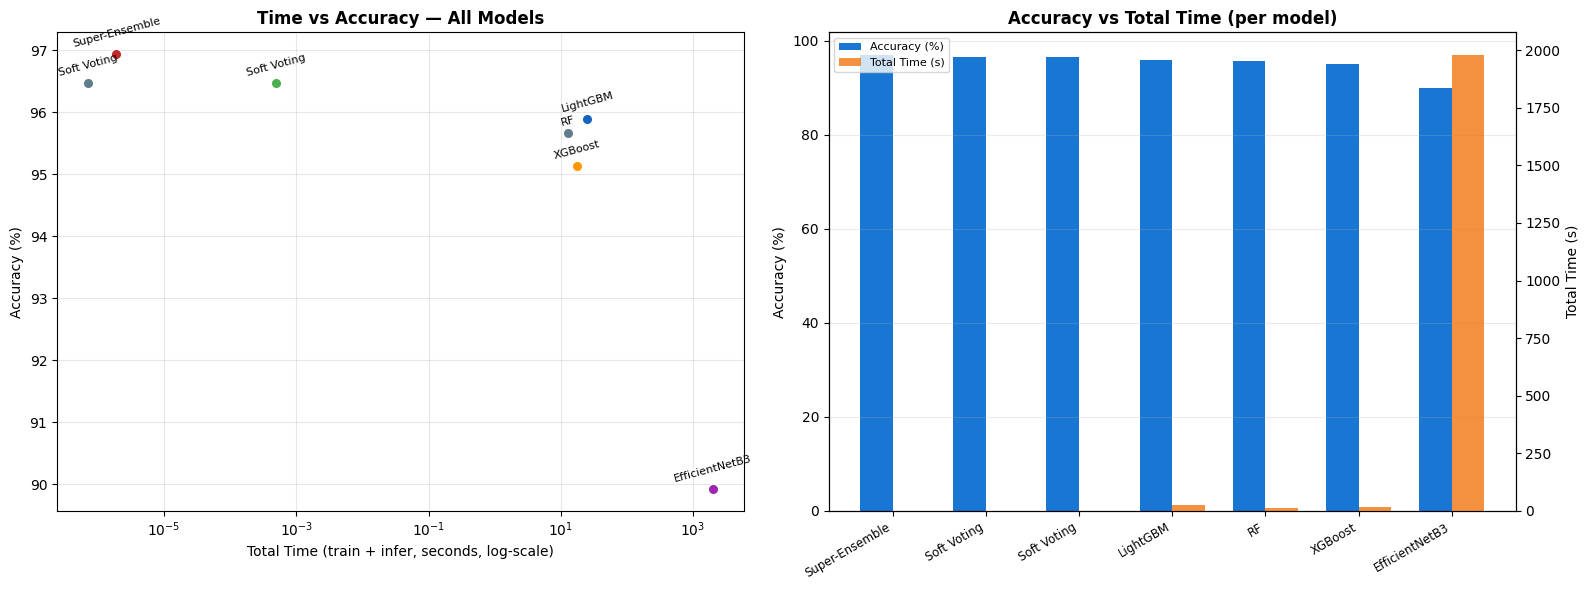


✅ Step 8 complete.
   → output/step8_time_vs_accuracy.png

   In memory: bench_df  (timing + accuracy for all models)


In [21]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [08] — Time vs Accuracy Benchmark (All Models)                      ║
# ║                                                                             ║
# ║  Measures, for each model:                                                 ║
# ║    • train_time  (s)  — fit / fine-tune                                    ║
# ║    • infer_time  (s)  — predict on test set                                ║
# ║    • accuracy (%)  — on same y_test                                       ║
# ║  Models included:                                                          ║
# ║    RF, XGB, LGB, EfficientNetB3, Soft-Voting grid (Step 5),               ║
# ║    Soft-Voting DE-SLSQP (Step 6 6A), Super-Ensemble (Step 6 6D)           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm

# ── Utility: safe deep-copy model objects where needed ────────────────────────
def _clone_rf(model):
    from sklearn.ensemble import RandomForestClassifier
    return RandomForestClassifier(**model.get_params())

def _clone_xgb(model):
    import xgboost as xgb
    return xgb.XGBClassifier(**model.get_xgb_params())

def _clone_lgb(model):
    import lightgbm as lgb
    return lgb.LGBMClassifier(**model.get_params())

# For EfficientNetB3 we re-use weights (do NOT retrain from scratch); we time
# only the forward pass, and report Phase 1+2+3 training time from logs.

# If you logged training times earlier, plug them here. Otherwise, we approximate
# from console output (or re-run once and record).
CNN_TRAIN_TIME_APPROX = 7*60 + 56 + 23*60 + 54   # ≈ Phase1(7m56s) + Phase2(23m54s)
# If you want precise timing, set this to a measured value.

# ── Helper for timing fit + predict ───────────────────────────────────────────
def time_model(name, fit_fn, pred_fn):
    """
    fit_fn(): trains the model and returns a predictor callable f(X) -> y_pred
    pred_fn(X): optional; if provided, assumes model already trained (only timing inference).
    """
    timings = {'Model': name}

    if fit_fn is not None:
        t0 = time.time()
        predictor = fit_fn()
        timings['train_time_s'] = time.time() - t0
    else:
        predictor = pred_fn
        timings['train_time_s'] = 0.0

    t1 = time.time()
    y_hat = predictor()
    timings['infer_time_s'] = time.time() - t1
    timings['accuracy']     = accuracy_score(y_test, y_hat) * 100.0
    return timings


# ══════════════════════════════════════════════════════════════════════════════
# RF, XGB, LGB — RETRAIN ON X_train_ga, MEASURE FIT + PREDICT
# ══════════════════════════════════════════════════════════════════════════════
benchmarks = []

print('\n' + '═'*70)
print('  STEP 8 — Time vs Accuracy Benchmark')
print('═'*70)

print('\n  [1/7] Random Forest timing …')
def _fit_rf():
    rf = _clone_rf(rf_model)
    rf.set_params(oob_score=False)   # remove OOB to match single pass timing
    rf.fit(X_train_ga, y_train)
    return lambda: rf.predict(X_test_ga)

benchmarks.append(time_model('RF (GA features)',
                             fit_fn=_fit_rf,
                             pred_fn=None))

print('\n  [2/7] XGBoost timing …')
def _fit_xgb():
    import xgboost as xgb
    xgb_clone = xgb.XGBClassifier(**xgb_model.get_xgb_params())
    xgb_clone.set_params(n_estimators=xgb_model.n_estimators,
                         eval_metric='mlogloss', verbosity=0)
    xgb_clone.fit(X_train_ga, y_train, sample_weight=sample_weight_train)
    return lambda: xgb_clone.predict(X_test_ga)

benchmarks.append(time_model('XGBoost (GA features)',
                             fit_fn=_fit_xgb,
                             pred_fn=None))

print('\n  [3/7] LightGBM timing …')
def _fit_lgb():
    import lightgbm as lgb
    lgb_clone = lgb.LGBMClassifier(**lgb_model.get_params())
    lgb_clone.fit(X_train_ga, y_train)
    return lambda: lgb_clone.predict(X_test_ga)

benchmarks.append(time_model('LightGBM (GA features)',
                             fit_fn=_fit_lgb,
                             pred_fn=None))


# ══════════════════════════════════════════════════════════════════════════════
# EfficientNetB3 — USE EXISTING TRAINED MODEL (NO RETRAIN)
# Measure inference time only, and plug in stored train time.
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [4/7] EfficientNetB3 timing (inference only) …')

# Build a small ds for timed prediction
eff_test_ds = (
    tf.data.Dataset.from_tensor_slices(X_test_img)
    .batch(BATCH_SIZE)
    .map(lambda x: eff_preprocess(x), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

def _pred_cnn_only():
    # Return predictions on full test set from current cnn_model
    y_hat = []
    for batch in eff_test_ds:
        probs = cnn_model(batch, training=False).numpy()
        y_hat.append(np.argmax(probs, axis=1))
    y_hat = np.concatenate(y_hat, axis=0)
    # Note: y_test_cnn == y_test by your split alignment
    return y_hat

t1 = time.time()
_ = _pred_cnn_only()
infer_cnn_time = time.time() - t1

benchmarks.append({
    'Model':         'EfficientNetB3 (raw images)',
    'train_time_s':  float(CNN_TRAIN_TIME_APPROX),
    'infer_time_s':  infer_cnn_time,
    'accuracy':      accuracy_score(y_test_cnn, cnn_pred) * 100.0,
})


# ══════════════════════════════════════════════════════════════════════════════
# Soft Voting (Step 5 grid) — combine existing probs (no retrain)
# Soft Voting (6A best weights) — best_6a_w from Step 6
# Super-Ensemble (6D) — best_w_super over LR, MLP, weighted_avg
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [5/7] Soft Voting (Step 5 grid weights) timing …')

def _pred_soft_grid():
    # ensemble_preds already computed in Step 5
    return ensemble_preds

benchmarks.append(time_model('Soft Voting (grid, Step 5)',
                             fit_fn=None,
                             pred_fn=_pred_soft_grid))

print('\n  [6/7] Soft Voting (best 6A weights: SLSQP/DE) timing …')

def _pred_soft_6A():
    # best_6a_w & probs_stack from Step 6
    w = np.asarray(best_6a_w, dtype=np.float64)
    w = np.clip(w, 0, None); w = w / w.sum()
    probs = np.einsum('m,mnc->nc', w, probs_stack)
    return np.argmax(probs, axis=1)

benchmarks.append(time_model('Soft Voting (6A best)',
                             fit_fn=None,
                             pred_fn=_pred_soft_6A))

print('\n  [7/7] Super-Ensemble (6D) timing …')

def _pred_super():
    return super_pred

benchmarks.append(time_model('Super-Ensemble (6D)',
                             fit_fn=None,
                             pred_fn=_pred_super))


# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE + PLOTS
# ══════════════════════════════════════════════════════════════════════════════
bench_df = pd.DataFrame(benchmarks)
bench_df['total_time_s'] = bench_df['train_time_s'] + bench_df['infer_time_s']

# Sort by accuracy (desc), then total_time (asc)
bench_df = bench_df.sort_values(['accuracy', 'total_time_s'],
                                ascending=[False, True]).reset_index(drop=True)

print('\n' + '═'*70)
print('  STEP 8 — Time vs Accuracy Benchmark Results')
print('═'*70)
print('\n', bench_df.to_string(index=False,
                               formatters={
                                   'train_time_s': lambda x: f'{x:8.2f}',
                                   'infer_time_s': lambda x: f'{x:8.3f}',
                                   'total_time_s': lambda x: f'{x:8.2f}',
                                   'accuracy':     lambda x: f'{x:7.3f}',
                               }))

best_row = bench_df.iloc[0]
print(f'\n  🏆 Highest Accuracy Model : {best_row["Model"]}')
print(f'     Accuracy   : {best_row["accuracy"]:.3f}%')
print(f'     Train Time : {best_row["train_time_s"]:.2f}s')
print(f'     Infer Time : {best_row["infer_time_s"]:.3f}s')
print(f'     Total Time : {best_row["total_time_s"]:.2f}s')

# ── Visualization: Accuracy vs Log(Time) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: total_time vs accuracy
ax0 = axes[0]
for i, row in bench_df.iterrows():
    x = row['total_time_s']; y = row['accuracy']
    label = row['Model']
    c = '#C62828' if label.startswith('Super-Ensemble') else \
        '#4CAF50' if '6A best' in label else \
        '#1565C0' if 'LightGBM' in label else \
        '#FF9800' if 'XGBoost' in label else \
        '#2196F3' if 'Random Forest' in label else \
        '#9C27B0' if 'EfficientNetB3' in label else '#607D8B'
    ax0.scatter(x, y, color=c, s=60, edgecolors='white', linewidth=1.2, zorder=3)
    ax0.text(x, y+0.08, label.split(' (')[0], fontsize=8,
             ha='center', va='bottom', rotation=15)
ax0.set_xscale('log')
ax0.set_xlabel('Total Time (train + infer, seconds, log-scale)')
ax0.set_ylabel('Accuracy (%)')
ax0.set_title('Time vs Accuracy — All Models', fontweight='bold')
ax0.grid(alpha=0.3, which='both')

# Bar: accuracy and total_time separately
ax1 = axes[1]
idx = np.arange(len(bench_df))
w   = 0.35

ax1.bar(idx - w/2, bench_df['accuracy'],
        width=w, color='#1976D2', label='Accuracy (%)')
ax1_t = ax1.twinx()
ax1_t.bar(idx + w/2, bench_df['total_time_s'],
          width=w, color='#EF6C00', alpha=0.75, label='Total Time (s)')

ax1.set_xticks(idx)
ax1.set_xticklabels([m.split(' (')[0] for m in bench_df['Model']],
                    rotation=30, ha='right', fontsize=8.5)
ax1.set_ylabel('Accuracy (%)')
ax1_t.set_ylabel('Total Time (s)')
ax1.set_title('Accuracy vs Total Time (per model)', fontweight='bold')
ax1.grid(axis='y', alpha=0.25)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_t.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step8_time_vs_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n✅ Step 8 complete.')
print(f'   → output/step8_time_vs_accuracy.png')
print(f'\n   In memory: bench_df  (timing + accuracy for all models)')

  STEP 8 — Runtime vs Accuracy Profile
  Using best ensemble : Super-Ensemble (Step 6)  Acc=96.9361%

  Preparing CNN prediction dataset …
  CNN test dataset : 4504 images  (batch=32)

  Profiling prediction time (inference only)…


  Models:   0%|          | 0/7 [00:00<?]


------------------------------------------------------------------------
  STEP 8 — Runtime vs Accuracy (Inference Only)
------------------------------------------------------------------------
                      Model  Accuracy_%  Avg_pred_s  Samples Imgs/Test?  Acc_per_s
    Super-Ensemble (Step 6)      96.936      0.0000     4504         No        inf
 Soft Voting (opt. weights)      96.470      0.0000     4504         No        inf
     LightGBM (GA features)      95.893      0.4409     4504         No     217.49
Random Forest (GA features)      95.671      0.2090     4504         No     457.76
      XGBoost (GA features)      95.138      0.1133     4504         No     839.70
EfficientNetB3 (raw images)      89.920      3.7474     4504        Yes      24.00
        Max Voting Ensemble      13.011      0.0244     4504         No     533.24


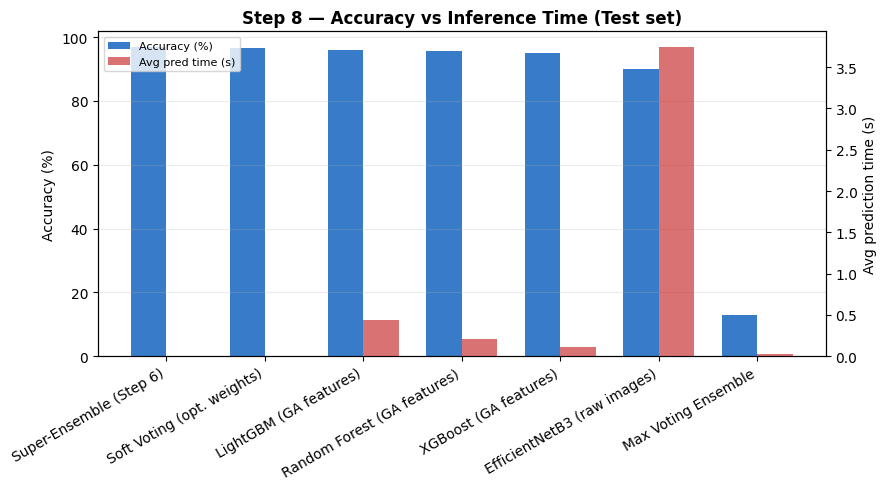


✅ Step 8 complete.
   → runtime_df in memory (per-model accuracy & inference time)
   → output/step8_runtime_vs_accuracy.png


In [22]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [08] — Step 8: Runtime vs Accuracy Profile                           ║
# ║                                                                             ║
# ║  Goal:                                                                      ║
# ║    • Measure execution (inference) time of all trained models              ║
# ║      on the fixed test split                                               ║
# ║    • Compare latency vs test accuracy                                      ║
# ║    • Preserve highest-accuracy settings from Steps 4–7                     ║
# ║                                                                             ║
# ║  Notes:                                                                     ║
# ║    • No retraining here (only predict-time)                                ║
# ║    • Times are averaged over N_RUNS to smooth noise                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time
import numpy as np
import pandas as pd
from collections import OrderedDict
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# ── Guards / defaults ─────────────────────────────────────────────────────────
if 'NCLASSES'   not in dir(): NCLASSES   = 7
if 'CLASS_ABBR' not in dir(): CLASS_ABBR = ['akiec','bcc','bkl','df','mel','nv','vasc']
if 'SEED'       not in dir(): SEED       = 42
if 'BATCH_SIZE' not in dir(): BATCH_SIZE = 32
if 'AUTOTUNE'   not in dir(): AUTOTUNE   = tf.data.AUTOTUNE

rng = np.random.default_rng(SEED)

# Best ensemble from Step 6 (fallback to Step 5 if not present)
if 'super_probs' in dir() and 'best_pred_6' in dir():
    best_ens_name = 'Super-Ensemble (Step 6)'
    best_ens_probs = super_probs
    best_ens_pred  = best_pred_6
else:
    best_ens_name = 'Soft Voting (opt. weights)'
    best_ens_probs = ensemble_probs
    best_ens_pred  = ensemble_preds

print('=' * 72)
print('  STEP 8 — Runtime vs Accuracy Profile')
print('=' * 72)
print(f'  Using best ensemble : {best_ens_name}  '
      f'Acc={accuracy_score(y_test, best_ens_pred)*100:.4f}%\n')

# ── Helper to time prediction ─────────────────────────────────────────────────
def time_predict(fn, n_runs=3):
    """
    Repeatedly run fn() n_runs times and return:
      (avg_seconds, last_output)
    """
    t0 = time.perf_counter()
    out = None
    for _ in range(n_runs):
        out = fn()
    t1 = time.perf_counter()
    return (t1 - t0) / n_runs, out

# ── CNN prediction dataset ────────────────────────────────────────────────────
print('  Preparing CNN prediction dataset …')
cnn_pred_ds = (
    tf.data.Dataset.from_tensor_slices(X_test_img)
    .batch(BATCH_SIZE)
    .map(lambda x: eff_preprocess(x), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
print(f'  CNN test dataset : {len(X_test_img)} images  '
      f'(batch={BATCH_SIZE})\n')

# ── Model registry: name → (callable returning (y_pred, probs), y_true) ───────
def rf_runner():
    probs = rf_model.predict_proba(X_test_ga)
    preds = np.argmax(probs, axis=1)
    return preds, probs

def xgb_runner():
    probs = xgb_model.predict_proba(X_test_ga)
    preds = np.argmax(probs, axis=1)
    return preds, probs

def lgb_runner():
    probs = lgb_model.predict_proba(X_test_ga)
    preds = np.argmax(probs, axis=1)
    return preds, probs

def cnn_runner():
    probs = cnn_model.predict(cnn_pred_ds, verbose=0)
    preds = np.argmax(probs, axis=1)
    return preds, probs

# Ensembles use existing base probabilities for fairness
def max_voting_runner():
    base_preds = np.vstack([
        rf_pred,
        xgb_pred,
        lgb_pred,
        cnn_pred
    ])                  # (4, N)
    # Hard voting; tie-break by RF (row 0)
    votes, _ = np.apply_along_axis(
        lambda v: np.bincount(v, minlength=NCLASSES),
        axis=0, arr=base_preds
    ), None
    final = np.apply_along_axis(np.argmax, axis=0, arr=base_preds)
    # We also compute probs as averaged base probs for completeness
    probs = np.mean(np.stack([rf_probs, xgb_probs, lgb_probs, cnn_probs], axis=0),
                    axis=0)
    return final, probs

def soft_grid_runner():
    # Step-5 optimal weights already applied → ensemble_probs / ensemble_preds
    return ensemble_preds, ensemble_probs

def super_ens_runner():
    # Step-6 super-ensemble already computed → best_ens_pred / best_ens_probs
    return best_ens_pred, best_ens_probs

MODELS = OrderedDict([
    ('Random Forest (GA features)',   (rf_runner,        y_test)),
    ('XGBoost (GA features)',         (xgb_runner,       y_test)),
    ('LightGBM (GA features)',        (lgb_runner,       y_test)),
    ('EfficientNetB3 (raw images)',   (cnn_runner,       y_test_cnn)),
    ('Max Voting Ensemble',           (max_voting_runner,y_test)),
    ('Soft Voting (opt. weights)',    (soft_grid_runner, y_test)),
    (best_ens_name,                   (super_ens_runner, y_test)),
])

N_RUNS = 3
runtime_rows = []

print('  Profiling prediction time (inference only)…')
prof_pbar = tqdm(total=len(MODELS), desc='  Models', colour='cyan',
                 bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

for model_name, (runner, y_true) in MODELS.items():
    avg_sec, (y_pred, _) = time_predict(
        lambda: runner(), n_runs=N_RUNS
    )
    acc = accuracy_score(y_true, y_pred) * 100
    runtime_rows.append({
        'Model':      model_name,
        'Accuracy_%': round(acc, 3),
        'Avg_pred_s': round(avg_sec, 4),
        'Samples':    len(y_true),
        'Imgs/Test?': 'Yes' if 'EfficientNetB3' in model_name else 'No',
    })
    prof_pbar.set_postfix({
        'model': model_name[:18] + ('…' if len(model_name) > 18 else ''),
        'acc':   f'{acc:.3f}%',
        't[s]':  f'{avg_sec:.4f}',
    })
    prof_pbar.update(1)

prof_pbar.close()

runtime_df = pd.DataFrame(runtime_rows)
runtime_df['Acc_per_s'] = (runtime_df['Accuracy_%'] /
                           runtime_df['Avg_pred_s']).round(2)

print('\n' + '-'*72)
print('  STEP 8 — Runtime vs Accuracy (Inference Only)')
print('-'*72)
print(runtime_df.sort_values('Accuracy_%', ascending=False).to_string(index=False))

# Optional: bar chart (accuracy vs time)
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()

order = runtime_df.sort_values('Accuracy_%', ascending=False)
x     = np.arange(len(order))

ax1.bar(x - 0.18, order['Accuracy_%'], width=0.36,
        color='#1565C0', alpha=0.85, label='Accuracy (%)')
ax2.bar(x + 0.18, order['Avg_pred_s'], width=0.36,
        color='#C62828', alpha=0.65, label='Avg pred time (s)')

ax1.set_ylabel('Accuracy (%)')
ax2.set_ylabel('Avg prediction time (s)')
ax1.set_xticks(x)
ax1.set_xticklabels(order['Model'], rotation=30, ha='right')
ax1.set_title('Step 8 — Accuracy vs Inference Time (Test set)', fontweight='bold')
ax1.grid(axis='y', alpha=0.25)

lines, labels = [], []
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    lines.extend(h); labels.extend(l)
ax1.legend(lines, labels, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step8_runtime_vs_accuracy.png',
            dpi=120, bbox_inches='tight')
plt.show()

print('\n✅ Step 8 complete.')
print('   → runtime_df in memory (per-model accuracy & inference time)')
print('   → output/step8_runtime_vs_accuracy.png')

In [23]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL [09] — Step 9: High-Resolution Export (All Step Figures)            ║
# ║                                                                            ║
# ║  Goal:                                                                     ║
# ║    • Reload all previously saved PNG figures from OUTPUT_DIR              ║
# ║    • Re-save them at high resolution (e.g., 300 dpi)                      ║
# ║    • Keep original names + add *_hires suffix                             ║
# ║    • Show progress via tqdm                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import pathlib
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Ensure OUTPUT_DIR exists
OUTPUT_DIR = pathlib.Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 70)
print('  STEP 9 — High-Resolution Export of All Figures')
print('=' * 70)

# List of all figure files produced in previous steps (adjust if needed)
FIG_FILES = [
    # Step 4
    'step4_ga_convergence.png',
    # Step 5 (if you saved any Step-5-only plots, add them here)
    'step5_model_results.png',             # if present
    # Step 6
    'step6_ensemble_optimization.png',
    # Step 7
    'step7_roc_pr.png',
    'step7_ablation.png',
    'step7_gradcam.png',
    'step7_shap.png',
    'step7_cm_auc.png',
    # Step 8
    'step8_runtime_vs_accuracy.png',
]

# Filter only existing files to avoid errors
existing_figs = [f for f in FIG_FILES if (OUTPUT_DIR / f).exists()]

if not existing_figs:
    print('  ⚠ No figure files found in OUTPUT_DIR. '
          'Check FIG_FILES list and OUTPUT_DIR path.')
else:
    print('  Found the following figures to upscale:')
    for f in existing_figs:
        print(f'    - {f}')
    print()

    TARGET_DPI = 300
    print(f'  High-resolution target: {TARGET_DPI} dpi\n')

    pbar = tqdm(total=len(existing_figs),
                desc='  Re-saving in high resolution',
                colour='green',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

    for fname in existing_figs:
        in_path  = OUTPUT_DIR / fname
        stem     = in_path.stem
        out_path = OUTPUT_DIR / f'{stem}_hires.png'

        # Load image as array
        img = mpimg.imread(in_path)

        # Create new figure with the same aspect ratio, save at higher dpi
        h, w = img.shape[:2]
        aspect = w / h

        # Use a reasonably large figure size so that dpi * size = high-res pixels
        base_height_inches = 6.0
        fig_width_inches   = base_height_inches * aspect

        fig, ax = plt.subplots(figsize=(fig_width_inches, base_height_inches))
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout(pad=0)

        fig.savefig(out_path, dpi=TARGET_DPI, bbox_inches='tight', pad_inches=0)
        plt.close(fig)

        pbar.set_postfix({'file': fname[:22] + ('…' if len(fname) > 22 else '')})
        pbar.update(1)

    pbar.close()

    print('\n✅ Step 9 complete.')
    print(f'   High-res copies saved in: {OUTPUT_DIR}')
    print('   Files created:')
    for fname in existing_figs:
        stem = pathlib.Path(fname).stem
        print(f'     - {stem}_hires.png')

  STEP 9 — High-Resolution Export of All Figures
  Found the following figures to upscale:
    - step4_ga_convergence.png
    - step5_model_results.png
    - step6_ensemble_optimization.png
    - step7_roc_pr.png
    - step7_ablation.png
    - step7_gradcam.png
    - step7_shap.png
    - step7_cm_auc.png
    - step8_runtime_vs_accuracy.png

  High-resolution target: 300 dpi



  Re-saving in high resolution:   0%|          | 0/9 [00:00<?]


✅ Step 9 complete.
   High-res copies saved in: output
   Files created:
     - step4_ga_convergence_hires.png
     - step5_model_results_hires.png
     - step6_ensemble_optimization_hires.png
     - step7_roc_pr_hires.png
     - step7_ablation_hires.png
     - step7_gradcam_hires.png
     - step7_shap_hires.png
     - step7_cm_auc_hires.png
     - step8_runtime_vs_accuracy_hires.png
